# Estimating Kg and l via Nonlinear Least Squares and Bayesian inversion

### Figure 2a

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 21 valid observations.
  - Year range: 1990 - 2022
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -3.0144 -> Kg = 0.0491
    l = 0.5553
    R² = 0.7931
    p-value = 0.0000
  - Performing nonlinear least squares fitting (with confidence intervals)...
  - Nonlinear least squares fitting results:
    K = 0.0540 (95% CI: [0.0394, 0.0731])
    l = 0.5219 (95% CI: [0.4186, 0.6342])
    R² = 0.7921
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.52, K = 0.0540, ln(K) = -2.9186


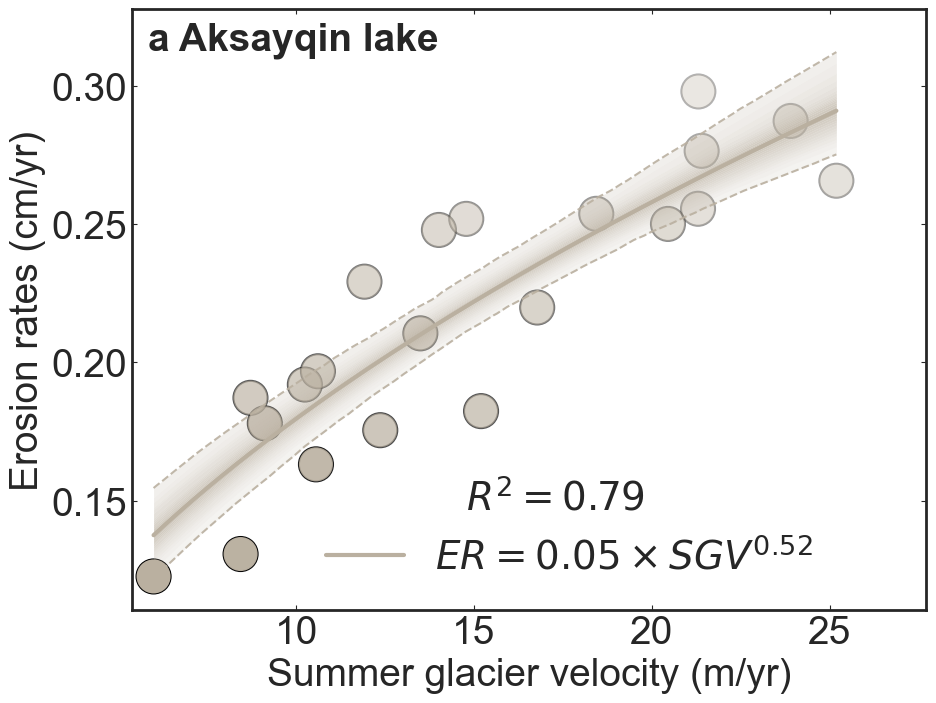

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Nonlinear_Analysis_TP_Table0926_A_only.png
  - Nonlinear least squares model R² = 0.792
  - Parameter confidence intervals: K: [0.0394, 0.0731], l: [0.4186, 0.6342]

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.5219        0.054        0.7921       21

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Aksayqin_Nonlinear_Analysis_Summary_A_only.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28  # Font size changed to 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-4, 1e2]  # Range of Keff
L_RANGE = [-0.90, 2.25]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function (with Confidence Interval Calculation)

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95):
    """Use nonlinear least squares to fit power law model, with confidence interval calculation"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            # Calculate confidence intervals using bootstrap method
            n_bootstrap = 1000
            bootstrap_K = []
            bootstrap_l = []
            n_samples = len(gv_obs)
            
            for _ in range(n_bootstrap):
                # Sampling with replacement
                indices = np.random.choice(n_samples, n_samples, replace=True)
                gv_bootstrap = gv_obs[indices]
                ssy_bootstrap = ssy_obs[indices]
                
                try:
                    # Fit bootstrap samples
                    bootstrap_result = optimize.least_squares(residuals, initial_guess, 
                                                            args=(gv_bootstrap, ssy_bootstrap), 
                                                            bounds=bounds, method='trf')
                    if bootstrap_result.success:
                        bootstrap_K.append(bootstrap_result.x[0])
                        bootstrap_l.append(bootstrap_result.x[1])
                except:
                    continue
            
            if len(bootstrap_K) > 0:
                # Calculate confidence intervals
                alpha = 1 - confidence
                K_ci_lower = np.percentile(bootstrap_K, alpha/2 * 100)
                K_ci_upper = np.percentile(bootstrap_K, (1 - alpha/2) * 100)
                l_ci_lower = np.percentile(bootstrap_l, alpha/2 * 100)
                l_ci_upper = np.percentile(bootstrap_l, (1 - alpha/2) * 100)
            else:
                K_ci_lower, K_ci_upper = K_opt, K_opt
                l_ci_lower, l_ci_upper = l_opt, l_opt
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f} (95% CI: [{K_ci_lower:.4f}, {K_ci_upper:.4f}])")
            print(f"    l = {l_opt:.4f} (95% CI: [{l_ci_lower:.4f}, {l_ci_upper:.4f}])")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev,
                'K_ci': (K_ci_lower, K_ci_upper),
                'l_ci': (l_ci_lower, l_ci_upper),
                'bootstrap_K': bootstrap_K,
                'bootstrap_l': bootstrap_l
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only Figure A) - With Gradient Effect

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only Figure A) - With gradient confidence interval"""
    
    # Get best fit parameters and confidence intervals from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
        # Get confidence intervals
        K_ci_lower, K_ci_upper = nonlinear_results.get('K_ci', (keff_best_fit, keff_best_fit))
        l_ci_lower, l_ci_upper = nonlinear_results.get('l_ci', (l_best_fit, l_best_fit))
        bootstrap_K = nonlinear_results.get('bootstrap_K', [])
        bootstrap_l = nonlinear_results.get('bootstrap_l', [])
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        # Set default confidence intervals
        K_ci_lower, K_ci_upper = keff_best_fit, keff_best_fit
        l_ci_lower, l_ci_upper = l_best_fit, l_best_fit
        bootstrap_K, bootstrap_l = [], []
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

     # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # Plot observation data points - using #BAB0A0 color, transparency based on year
    # First draw outer ring (black border)
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='none', edgecolors='black', 
               linewidths=1.5, s=600, alpha=alpha_values_year[i])
    # Then draw inner filled points    
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='#BAB0A0', alpha=alpha_values_year[i], s=600, edgecolors='none')
   
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-10, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot nonlinear least squares best fit curve (power law model) - using lake-specific color
    ssy_fit_nonlinear = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_nonlinear, color='#BAB0A0', linewidth=3, 
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Plot gradient confidence interval - retain gradient effect
    if len(bootstrap_K) > 0 and len(bootstrap_l) > 0:
        # Calculate multiple percentile predictions to achieve gradient effect
        # Increase layers to 30 for smoother gradient
        percentiles = np.linspace(2.5, 97.5, 30)
        
        # Store predictions for each percentile
        predictions_by_percentile = []
        
        for gv_val in gv_fit:
            # Calculate predictions for all bootstrap samples for each gv value
            predictions = []
            for i in range(len(bootstrap_K)):
                predictions.append(bootstrap_K[i] * (gv_val ** bootstrap_l[i]))
            
            if predictions:
                # Calculate multiple percentile values
                percentiles_values = np.percentile(predictions, percentiles)
                predictions_by_percentile.append(percentiles_values)
            else:
                predictions_by_percentile.append([keff_best_fit * (gv_val ** l_best_fit)] * len(percentiles))
        
        # Convert to array
        predictions_by_percentile = np.array(predictions_by_percentile).T
        
        # Create gradient fill effect
        for i in range(len(percentiles) - 1):
            # Calculate gradient transparency: center line least transparent, edges most transparent
            # Adjust parameters to make colors darker while maintaining gradient effect
            # Center transparency 0.6, edge transparency 0.15
            alpha_val = 0.6 * (1 - abs(50 - percentiles[i]) / 47.5) + 0.15
            
            # Use gradient color fill
            color = '#BAB0A0'
            
            # Fill area between two percentiles
            ax.fill_between(gv_fit, 
                          predictions_by_percentile[i], 
                          predictions_by_percentile[i+1], 
                          color=color, 
                          alpha=alpha_val,
                          linewidth=0)
        
        # Add outer boundary lines - keep dashed borders
        ax.plot(gv_fit, predictions_by_percentile[0], color='#BAB0A0', linewidth=1.5, alpha=0.9, linestyle='--')
        ax.plot(gv_fit, predictions_by_percentile[-1], color='#BAB0A0', linewidth=1.5, alpha=0.9, linestyle='--')
    
    # Add R² annotation (only show nonlinear least squares R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_nonlinear:.2f}$', transform=ax.transAxes, 
            fontsize=28, verticalalignment='top',  # R² font size changed to 28
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)  # x-axis label font size changed to 28
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)  # y-axis label font size changed to 28
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=28)
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=28)  # Legend font size changed to 28

    ax.set_xlim(gv_obs.min()*0.9, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'a Aksayqin lake', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')  # Subplot label font size changed to 28
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter confidence intervals: K: [{K_ci_lower:.4f}, {K_ci_upper:.4f}], l: [{l_ci_lower:.4f}, {l_ci_upper:.4f}]")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting (with confidence intervals)
    print(f"  - Performing nonlinear least squares fitting (with confidence intervals)...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Aksayqin_Nonlinear_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 2b

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 27 valid observations.
  - Year range: 1987 - 2013
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8956 -> Kg = 0.1502
    l = 0.2833
    R² = 0.5969
    p-value = 0.0000
  - Performing nonlinear least squares fitting (with confidence intervals)...
  - Nonlinear least squares fitting results:
    K = 0.1574 (95% CI: [0.1199, 0.2032])
    l = 0.2730 (95% CI: [0.2119, 0.3425])
    R² = 0.6695
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.27, K = 0.1574, ln(K) = -1.8488


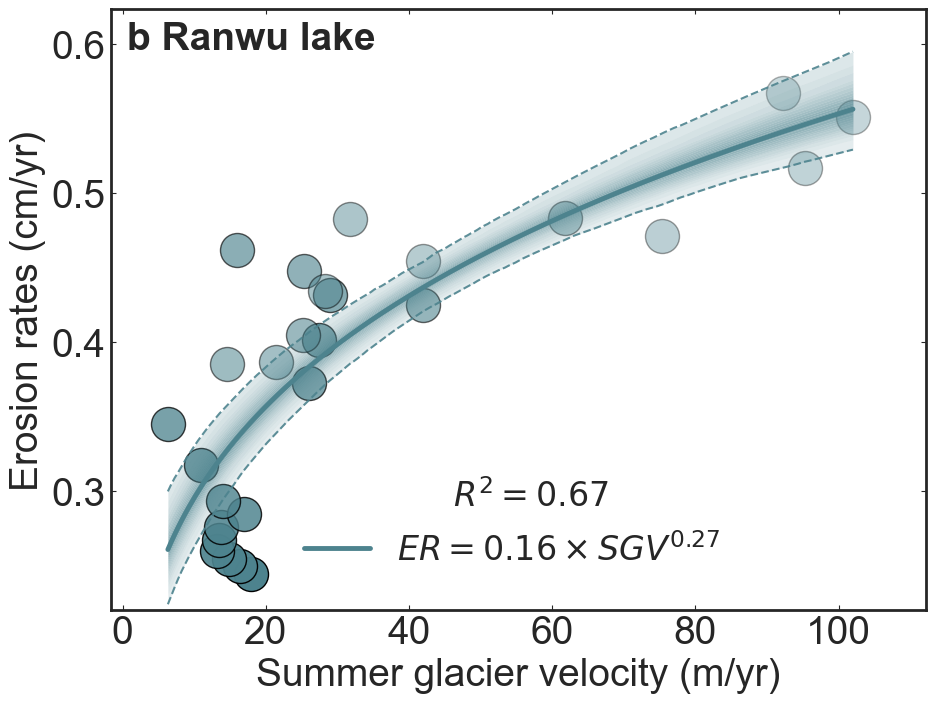

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Nonlinear_Analysis_TP_Table0926_A_only.png
  - Nonlinear least squares model R² = 0.670
  - Parameter confidence intervals: K: [0.1199, 0.2032], l: [0.2119, 0.3425]

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926        0.273       0.1574        0.6695       27

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Ranwu_Nonlinear_Analysis_Summary_A_only.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28  # Font size changed to 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 600000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.60, 1.5]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function (with Confidence Interval Calculation)

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95):
    """Use nonlinear least squares to fit power law model, with confidence interval calculation"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            # Calculate confidence intervals using bootstrap method
            n_bootstrap = 1000
            bootstrap_K = []
            bootstrap_l = []
            n_samples = len(gv_obs)
            
            for _ in range(n_bootstrap):
                # Sampling with replacement
                indices = np.random.choice(n_samples, n_samples, replace=True)
                gv_bootstrap = gv_obs[indices]
                ssy_bootstrap = ssy_obs[indices]
                
                try:
                    # Fit bootstrap samples
                    bootstrap_result = optimize.least_squares(residuals, initial_guess, 
                                                            args=(gv_bootstrap, ssy_bootstrap), 
                                                            bounds=bounds, method='trf')
                    if bootstrap_result.success:
                        bootstrap_K.append(bootstrap_result.x[0])
                        bootstrap_l.append(bootstrap_result.x[1])
                except:
                    continue
            
            if len(bootstrap_K) > 0:
                # Calculate confidence intervals
                alpha = 1 - confidence
                K_ci_lower = np.percentile(bootstrap_K, alpha/2 * 100)
                K_ci_upper = np.percentile(bootstrap_K, (1 - alpha/2) * 100)
                l_ci_lower = np.percentile(bootstrap_l, alpha/2 * 100)
                l_ci_upper = np.percentile(bootstrap_l, (1 - alpha/2) * 100)
            else:
                K_ci_lower, K_ci_upper = K_opt, K_opt
                l_ci_lower, l_ci_upper = l_opt, l_opt
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f} (95% CI: [{K_ci_lower:.4f}, {K_ci_upper:.4f}])")
            print(f"    l = {l_opt:.4f} (95% CI: [{l_ci_lower:.4f}, {l_ci_upper:.4f}])")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev,
                'K_ci': (K_ci_lower, K_ci_upper),
                'l_ci': (l_ci_lower, l_ci_upper),
                'bootstrap_K': bootstrap_K,
                'bootstrap_l': bootstrap_l
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only Figure A) - With Gradient Confidence Interval

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only Figure A) - With gradient confidence interval"""
    
    # Get best fit parameters and confidence intervals from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
        # Get confidence intervals
        K_ci_lower, K_ci_upper = nonlinear_results.get('K_ci', (keff_best_fit, keff_best_fit))
        l_ci_lower, l_ci_upper = nonlinear_results.get('l_ci', (l_best_fit, l_best_fit))
        bootstrap_K = nonlinear_results.get('bootstrap_K', [])
        bootstrap_l = nonlinear_results.get('bootstrap_l', [])
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        # Set default confidence intervals
        K_ci_lower, K_ci_upper = keff_best_fit, keff_best_fit
        l_ci_lower, l_ci_upper = l_best_fit, l_best_fit
        bootstrap_K, bootstrap_l = [], []
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))  # Adjust size to accommodate large font
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True, labelsize=28)  # Tick label font size 28

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # Plot observation data points - using #4D838E color, transparency based on year
    # Modified: draw once, with both border and fill, avoiding overlap
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], 
                   c='#4D838E',  # Fill color
                   edgecolors='black',  # Border color
                   linewidths=1,  # Border line width
                   s=600,  # Point size
                   alpha=alpha_values_year[i])  # Transparency
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-9, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot nonlinear least squares best fit curve (power law model) - using lake-specific color #4D838E
    ssy_fit_nonlinear = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_nonlinear, color='#4D838E', linewidth=3.5, 
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Plot gradient confidence interval - retain gradient effect, color using #4D838E
    if len(bootstrap_K) > 0 and len(bootstrap_l) > 0:
        # Calculate multiple percentile predictions to achieve gradient effect
        # Increase layers to 30 for smoother gradient
        percentiles = np.linspace(2.5, 97.5, 30)
        
        # Store predictions for each percentile
        predictions_by_percentile = []
        
        for gv_val in gv_fit:
            # Calculate predictions for all bootstrap samples for each gv value
            predictions = []
            for i in range(len(bootstrap_K)):
                predictions.append(bootstrap_K[i] * (gv_val ** bootstrap_l[i]))
            
            if predictions:
                # Calculate multiple percentile values
                percentiles_values = np.percentile(predictions, percentiles)
                predictions_by_percentile.append(percentiles_values)
            else:
                predictions_by_percentile.append([keff_best_fit * (gv_val ** l_best_fit)] * len(percentiles))
        
        # Convert to array
        predictions_by_percentile = np.array(predictions_by_percentile).T
        
        # Create gradient fill effect
        for i in range(len(percentiles) - 1):
            # Calculate gradient transparency: center line least transparent, edges most transparent
            # Adjust parameters to make colors darker while maintaining gradient effect
            # Center transparency 0.6, edge transparency 0.15
            alpha_val = 0.6 * (1 - abs(50 - percentiles[i]) / 47.5) + 0.15
            
            # Use gradient color fill
            color = '#4D838E'  # Ranwu lake color
            
            # Fill area between two percentiles
            ax.fill_between(gv_fit, 
                          predictions_by_percentile[i], 
                          predictions_by_percentile[i+1], 
                          color=color, 
                          alpha=alpha_val,
                          linewidth=0)
        
        # Add outer boundary lines - keep dashed borders
        ax.plot(gv_fit, predictions_by_percentile[0], color='#4D838E', linewidth=1.5, alpha=0.9, linestyle='--')
        ax.plot(gv_fit, predictions_by_percentile[-1], color='#4D838E', linewidth=1.5, alpha=0.9, linestyle='--')
    
    # Add R² annotation (only show nonlinear least squares R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_nonlinear:.2f}$', transform=ax.transAxes, 
            fontsize=24, verticalalignment='top',  # R² font size slightly smaller
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)  # X-axis label font size 28
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)  # Y-axis label font size 28
    
    # Set tick label font size
    ax.tick_params(axis='both', which='major', labelsize=28)
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=24)  # Legend font size 24

    ax.set_xlim(gv_obs.min()-8, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'b Ranwu lake', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')  # Subplot label font size 28
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter confidence intervals: K: [{K_ci_lower:.4f}, {K_ci_upper:.4f}], l: [{l_ci_lower:.4f}, {l_ci_upper:.4f}]")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting (with confidence intervals)
    print(f"  - Performing nonlinear least squares fitting (with confidence intervals)...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Ranwu_Nonlinear_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 2c

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 32 valid observations.
  - Year range: 1987 - 2018
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8603 -> Kg = 0.1556
    l = 0.2621
    R² = 0.7307
    p-value = 0.0000
  - Performing nonlinear least squares fitting (with confidence intervals)...
  - Nonlinear least squares fitting results:
    K = 0.1391 (95% CI: [0.1032, 0.1779])
    l = 0.2928 (95% CI: [0.2350, 0.3580])
    R² = 0.7931
    Iterations: 6
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.29, K = 0.1391, ln(K) = -1.9723


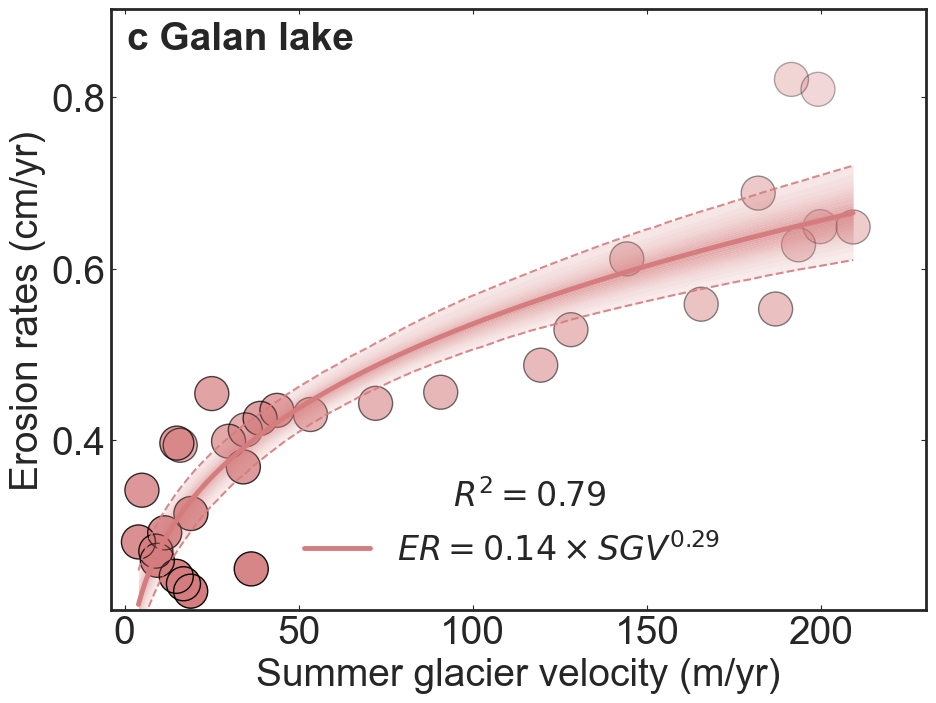

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Nonlinear_Analysis_TP_Table0926_A_only.png
  - Nonlinear least squares model R² = 0.793
  - Parameter confidence intervals: K: [0.1032, 0.1779], l: [0.2350, 0.3580]

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.2928       0.1391        0.7931       32

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Nonlinear_Analysis_Summary_A_only.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28  # Font size changed to 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.50, 1.7]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function (with Confidence Interval Calculation)

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95):
    """Use nonlinear least squares to fit power law model, with confidence interval calculation"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            # Calculate confidence intervals using bootstrap method
            n_bootstrap = 1000
            bootstrap_K = []
            bootstrap_l = []
            n_samples = len(gv_obs)
            
            for _ in range(n_bootstrap):
                # Sampling with replacement
                indices = np.random.choice(n_samples, n_samples, replace=True)
                gv_bootstrap = gv_obs[indices]
                ssy_bootstrap = ssy_obs[indices]
                
                try:
                    # Fit bootstrap samples
                    bootstrap_result = optimize.least_squares(residuals, initial_guess, 
                                                            args=(gv_bootstrap, ssy_bootstrap), 
                                                            bounds=bounds, method='trf')
                    if bootstrap_result.success:
                        bootstrap_K.append(bootstrap_result.x[0])
                        bootstrap_l.append(bootstrap_result.x[1])
                except:
                    continue
            
            if len(bootstrap_K) > 0:
                # Calculate confidence intervals
                alpha = 1 - confidence
                K_ci_lower = np.percentile(bootstrap_K, alpha/2 * 100)
                K_ci_upper = np.percentile(bootstrap_K, (1 - alpha/2) * 100)
                l_ci_lower = np.percentile(bootstrap_l, alpha/2 * 100)
                l_ci_upper = np.percentile(bootstrap_l, (1 - alpha/2) * 100)
            else:
                K_ci_lower, K_ci_upper = K_opt, K_opt
                l_ci_lower, l_ci_upper = l_opt, l_opt
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f} (95% CI: [{K_ci_lower:.4f}, {K_ci_upper:.4f}])")
            print(f"    l = {l_opt:.4f} (95% CI: [{l_ci_lower:.4f}, {l_ci_upper:.4f}])")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev,
                'K_ci': (K_ci_lower, K_ci_upper),
                'l_ci': (l_ci_lower, l_ci_upper),
                'bootstrap_K': bootstrap_K,
                'bootstrap_l': bootstrap_l
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    likelihood_per_model = np.exp(-0.5 * rss_per_model / np.var(ssy_obs))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only Figure A) - With Gradient Confidence Interval

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only Figure A) - With gradient confidence interval"""
    
    # Get best fit parameters and confidence intervals from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
        # Get confidence intervals
        K_ci_lower, K_ci_upper = nonlinear_results.get('K_ci', (keff_best_fit, keff_best_fit))
        l_ci_lower, l_ci_upper = nonlinear_results.get('l_ci', (l_best_fit, l_best_fit))
        bootstrap_K = nonlinear_results.get('bootstrap_K', [])
        bootstrap_l = nonlinear_results.get('bootstrap_l', [])
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        # Set default confidence intervals
        K_ci_lower, K_ci_upper = keff_best_fit, keff_best_fit
        l_ci_lower, l_ci_upper = l_best_fit, l_best_fit
        bootstrap_K, bootstrap_l = [], []
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True, labelsize=28)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # First draw all inner filled points - using #D57D7E color, transparency based on year
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='#D57D7E', alpha=alpha_values_year[i], s=600, edgecolors='none')
    
    # Then draw all outer rings (black borders) - ensure borders are not obscured
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='none', edgecolors='black', 
               linewidths=1, s=600, alpha=alpha_values_year[i])
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-9, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot nonlinear least squares best fit curve (power law model) - using lake-specific color
    ssy_fit_nonlinear = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_nonlinear, color='#D57D7E', linewidth=3.5, 
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Plot gradient confidence interval - using lake color #D57D7E
    if len(bootstrap_K) > 0 and len(bootstrap_l) > 0:
        # Calculate multiple percentile predictions to achieve gradient effect
        # Increase layers to 30 for smoother gradient
        percentiles = np.linspace(2.5, 97.5, 30)
        
        # Store predictions for each percentile
        predictions_by_percentile = []
        
        for gv_val in gv_fit:
            # Calculate predictions for all bootstrap samples for each gv value
            predictions = []
            for i in range(len(bootstrap_K)):
                predictions.append(bootstrap_K[i] * (gv_val ** bootstrap_l[i]))
            
            if predictions:
                # Calculate multiple percentile values
                percentiles_values = np.percentile(predictions, percentiles)
                predictions_by_percentile.append(percentiles_values)
            else:
                predictions_by_percentile.append([keff_best_fit * (gv_val ** l_best_fit)] * len(percentiles))
        
        # Convert to array
        predictions_by_percentile = np.array(predictions_by_percentile).T
        
        # Create gradient fill effect
        for i in range(len(percentiles) - 1):
            # Calculate gradient transparency: center line least transparent, edges most transparent
            # Adjust parameters to make colors darker while maintaining gradient effect
            # Center transparency 0.6, edge transparency 0.15
            alpha_val = 0.6 * (1 - abs(50 - percentiles[i]) / 47.5) + 0.15
            
            # Use lake color #D57D7E
            color = '#D57D7E'
            
            # Fill area between two percentiles
            ax.fill_between(gv_fit, 
                          predictions_by_percentile[i], 
                          predictions_by_percentile[i+1], 
                          color=color, 
                          alpha=alpha_val,
                          linewidth=0)
        
        # Add outer boundary lines - using lake color
        ax.plot(gv_fit, predictions_by_percentile[0], color='#D57D7E', linewidth=1.5, alpha=0.9, linestyle='--')
        ax.plot(gv_fit, predictions_by_percentile[-1], color='#D57D7E', linewidth=1.5, alpha=0.9, linestyle='--')
    
    # Add R² annotation (only show nonlinear least squares R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_nonlinear:.2f}$', transform=ax.transAxes, 
            fontsize=24, verticalalignment='top',  # R² font size slightly smaller
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)  # X-axis label font size 28
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)  # Y-axis label font size 28
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=24)  # Legend font size 24

    ax.set_xlim(gv_obs.min()-8, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'c Galan lake', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')  # Subplot label font size 28
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter confidence intervals: K: [{K_ci_lower:.4f}, {K_ci_upper:.4f}], l: [{l_ci_lower:.4f}, {l_ci_upper:.4f}]")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting (with confidence intervals)
    print(f"  - Performing nonlinear least squares fitting (with confidence intervals)...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs, confidence=0.95)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Nonlinear_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

## The probability density function of the constrained parameters

### Figure 3 a

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 21 valid observations.
  - Year range: 1990 - 2022
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -3.0144 -> Kg = 0.0491
    l = 0.5553
    R² = 0.7931
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.0540
    l = 0.5219
    R² = 0.7921
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.52, K = 0.0540, ln(K) = -2.9186
  - Number of accepted parameters: 5000
  - l parameter range: [-0.056, 1.184]
  - ln(K) parameter range: [-4.848, -1.367]
  - Maximum density value: 2.550e+00
  - Figure size: (18.0, 15.0)
  - Bandwidth factor: 1.0


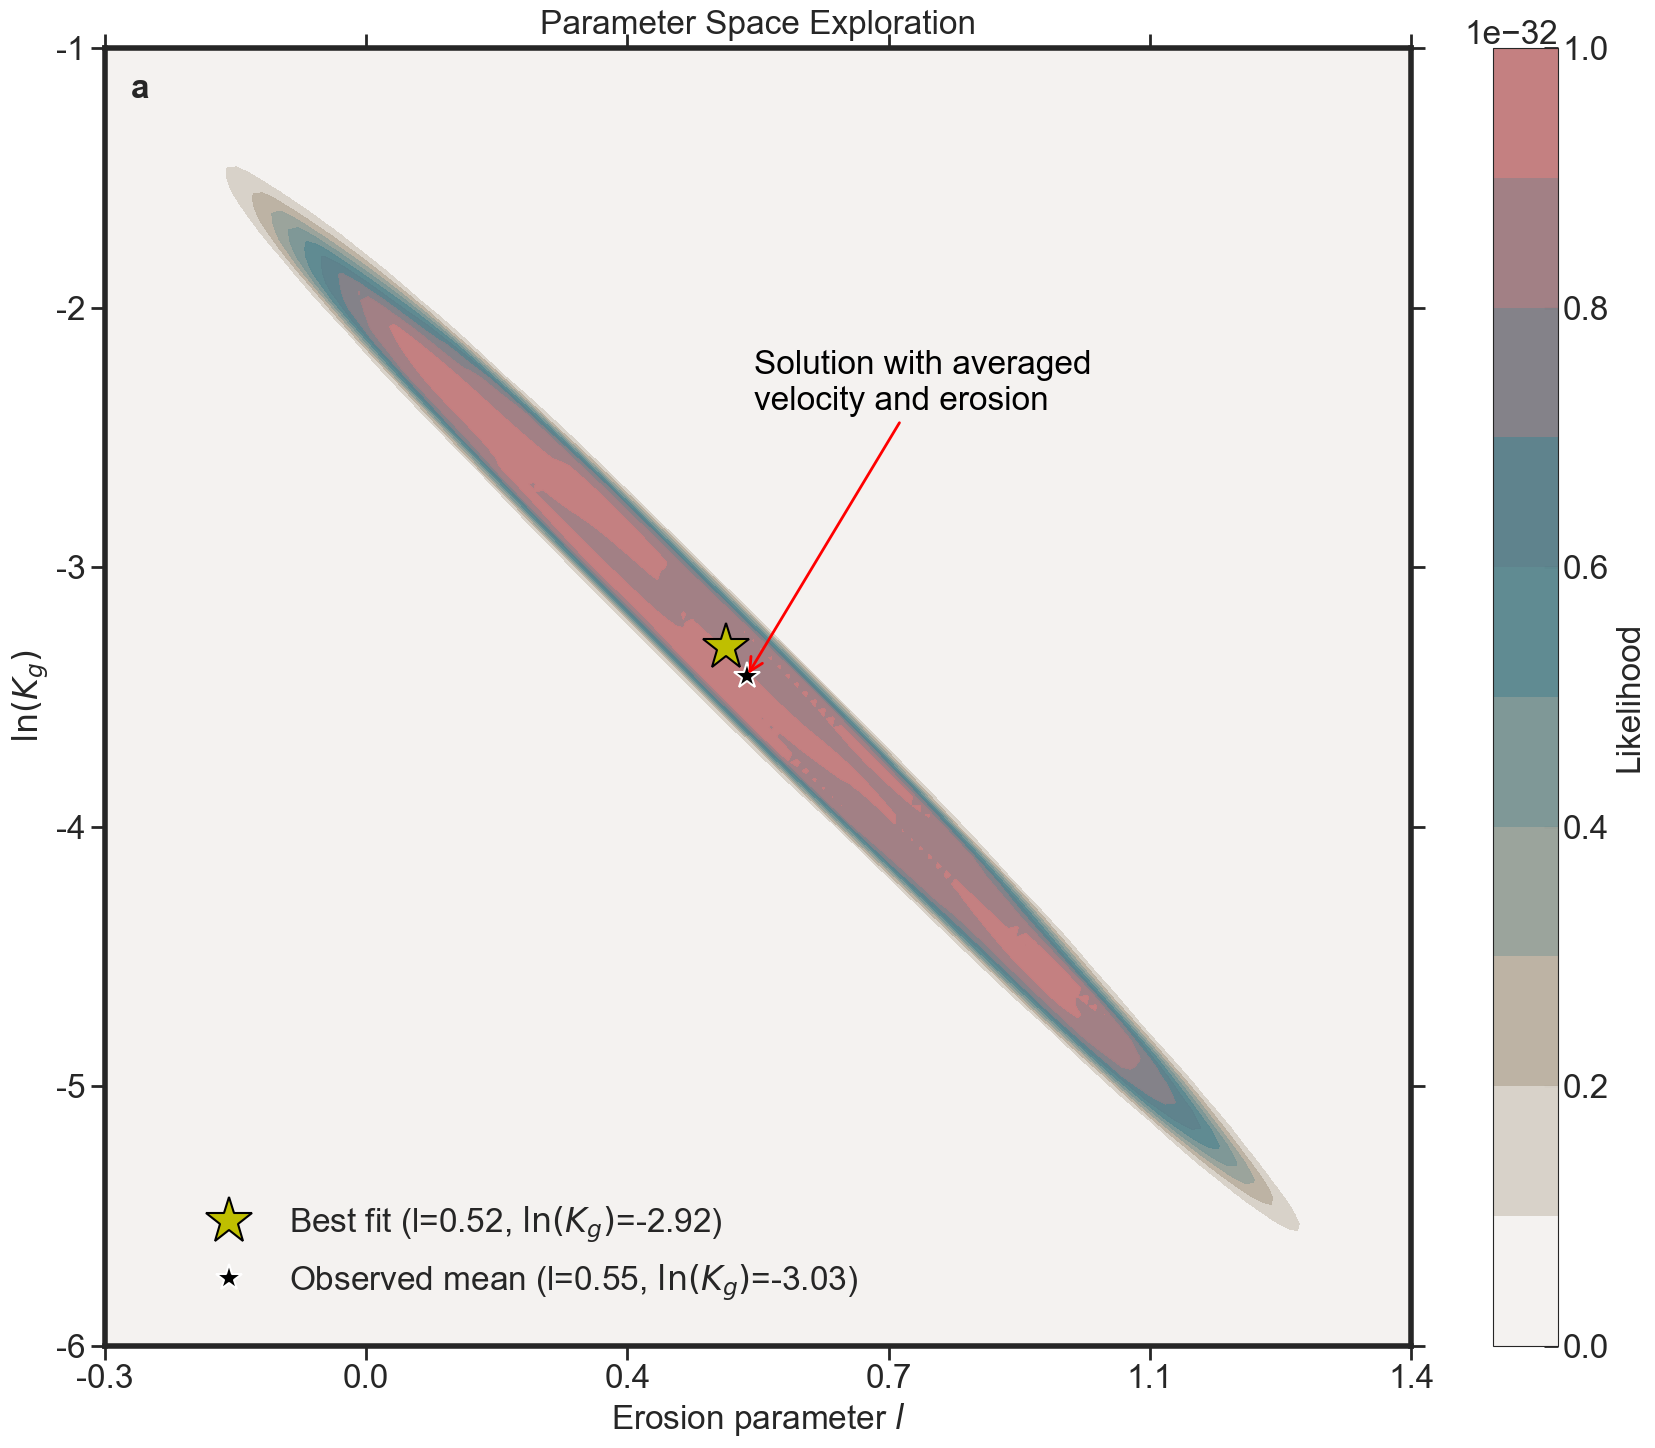

  - Subplot B complete! 'TP_Table0926' parameter trade-off plot saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Subplot_B_Only_TP_Table0926.png
  - Nonlinear least squares model R² = 0.792
  - Parameter mean point: l = 0.549, ln(K) = -3.030, K = 0.048

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.5219        0.054        0.7921       21

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Aksayqin_Nonlinear_Analysis_Summary_B_only.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
from matplotlib.ticker import AutoMinorLocator

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24  # Font size changed to 24
sns.set_style("white")  # Use pure white background

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 1.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-4, 1e2]  # Range of Keff
L_RANGE = [-0.90, 2.25]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Only Subplot B (Increased Center Density and Figure Size) - Aksayqin Lake Version

# %%
def plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate only subplot B: Parameter trade-off plot (increased center density and figure size) - Aksayqin lake version"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters - use stricter threshold to obtain more concentrated parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Using 2% threshold.")
        likelihood_threshold = np.percentile(likelihood_per_model, 98.0)
        accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure - only show subplot B, enlarge 1.5 times (consistent with other lakes)
    enlarged_figsize = (12 * 1.5, 10 * 1.5)  # Enlarge 1.5 times, consistent with other lakes
    fig, ax = plt.subplots(1, 1, figsize=enlarged_figsize)
    
    # Figure B: Parameter trade-off plot (using natural logarithm)
    # Set tick marks - show tick marks on all four sides
    ax.tick_params(axis='both', which='major', 
                  direction='out',  # Tick mark direction outward
                  top=True, right=True, bottom=True, left=True,  # Show ticks on all four sides
                  length=10, width=2,  # Tick mark length and width
                  labelsize=24)  # Tick label size
    
    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(4)  # Set border line thickness
        
    # Increase the display range of density plots - use larger vmax_value
    vmax_value = 1e-32  # Use larger vmax_value
    
    # Create custom color map: set color gradient according to specified ranges
    # white: 0-2.5e-33, #BAB0A0: 2.5e-33-6e-33, #4D838E: 6e-33-9e-33, #D57D7E: 9e-33-1e-32
    colors = ['white', '#BAB0A0', '#4D838E', '#D57D7E']
    
    # Create color map nodes (0, 0.25, 0.6, 1.0 corresponding to 0, 2.5e-33, 6e-33, 1e-32)
    color_nodes = [0, 2.5e-33/vmax_value, 6e-33/vmax_value, 1.0]
    
    n_bins = 100
    cmap_custom = LinearSegmentedColormap.from_list('custom_cmap', 
                                                   list(zip(color_nodes, colors)), 
                                                   N=n_bins)
    
    # Create grid for confidence band - use same parameters as other lakes
    l_min, l_max = accepted_l.min(), accepted_l.max()
    ln_keff_min, ln_keff_max = accepted_ln_keff.min(), accepted_ln_keff.max()
    
    # Leave some space around parameters
    l_range = l_max - l_min
    ln_keff_range = ln_keff_max - ln_keff_min
    
    # Use same boundary settings as other lakes, but adjust according to Aksayqin lake's L_RANGE
    l_grid_min = max(l_min - 0.2 * l_range, -1.0)  # Use fixed boundaries, considering L_RANGE starts from -0.90
    l_grid_max = min(l_max + 0.2 * l_range, 2.4)   # Use fixed boundaries, considering L_RANGE goes to 2.25
    ln_keff_grid_min = max(ln_keff_min - 0.2 * ln_keff_range, np.log(KEFF_RANGE[0]))
    ln_keff_grid_max = min(ln_keff_max + 0.2 * ln_keff_range, np.log(KEFF_RANGE[1]))
    
    # Create denser grid
    l_grid = np.linspace(l_grid_min, l_grid_max, 150)  # Increased from 100 to 150
    ln_keff_grid = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 150)  # Increased from 100 to 150
    L_grid, LN_Keff_grid = np.meshgrid(l_grid, ln_keff_grid)
    
    # Create KDE using accepted high likelihood parameters - use larger bandwidth factor to obtain more dispersed density
    accepted_data = np.vstack([accepted_l, accepted_ln_keff])
    
    # Calculate using Scott's rule, then use larger bandwidth factor
    n_points = accepted_data.shape[1]
    scott_factor = n_points ** (-1./(accepted_data.shape[0] + 4))
    
    # Increase bandwidth factor to obtain more dispersed density (consistent with other lakes)
    bandwidth_factor = 1.0  # Increase bandwidth factor from 0.5 to 1.0
    kde = gaussian_kde(accepted_data, bw_method=scott_factor * bandwidth_factor)
    
    # Calculate probability density on grid
    grid_points = np.vstack([L_grid.ravel(), LN_Keff_grid.ravel()])
    density = kde(grid_points).reshape(L_grid.shape)
    
    # Normalize probability density to [0, vmax_value] range
    density_normalized = density / density.max() * vmax_value
    
    # Plot confidence band - use more levels to achieve smoother transition
    contour = ax.contourf(L_grid, LN_Keff_grid, density_normalized, 
                         levels=10, cmap=cmap_custom,  # Keep 10 levels
                         vmin=0, vmax=vmax_value, alpha=0.99)  # Increase transparency to 0.99
    
    # Mark nonlinear least squares best fit point - using yellow star
    ax.plot(l_best_fit, ln_keff_best_fit, 'y*', markersize=35, 
            markeredgecolor='black', markeredgewidth=1.5,
            label=f'Best fit (l={l_best_fit:.2f}, $\ln(K_g)$={ln_keff_best_fit:.2f})')
    
    # Use average of accepted parameters as mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    
    # Mark data mean point - using black star
    ax.plot(l_mean, ln_keff_mean, 'k*', markersize=20, 
            markeredgecolor='white', markeredgewidth=1.5,
            label=f'Observed mean (l={l_mean:.2f}, $\ln(K_g)$={ln_keff_mean:.2f})')
    
    # Add text annotation
    ax.annotate('Solution with averaged\nvelocity and erosion', xy=(l_mean, ln_keff_mean), 
                xytext=(l_mean + 0.01, ln_keff_mean + 1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=24, color='black')
    
    # Add color bar and set label
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Likelihood', fontsize=24)
    
    # Set color bar tick marks
    cbar.ax.tick_params(labelsize=24, length=10, width=2, direction='in')
    
    # Set axis labels
    ax.set_xlabel('Erosion parameter $l$', fontsize=24)
    ax.set_ylabel('$\ln(K_g)$', fontsize=24)
    
    # Use coordinate position to control legend
    legend = ax.legend(loc='lower right', bbox_to_anchor=(0.6, 0.01),  # Adjust legend position
                  frameon=False, framealpha=0.8, fontsize=24)
    
    # Set axis ranges - use same range settings as other lakes
    ax.set_xlim(l_grid_min, l_grid_max)
    ax.set_ylim(ln_keff_grid_min, ln_keff_grid_max)

    # Set x-axis ticks - based on actual range
    x_ticks = np.linspace(l_grid_min, l_grid_max, 6)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=24)
    
    # Set x-axis minor ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    # Set y-axis ticks - based on actual range
    y_ticks = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 6)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{y:.0f}' for y in y_ticks], fontsize=24)
    
    # Set y-axis minor ticks
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    # Add subplot label - changed to 'a' because this is the first lake
    ax.text(0.02, 0.98, 'a', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
    
    # Add title
    ax.set_title('Parameter Space Exploration', fontsize=24, pad=10)
    
    # Display parameter density information
    print(f"  - Number of accepted parameters: {len(accepted_indices)}")
    print(f"  - l parameter range: [{accepted_l.min():.3f}, {accepted_l.max():.3f}]")
    print(f"  - ln(K) parameter range: [{accepted_ln_keff.min():.3f}, {accepted_ln_keff.max():.3f}]")
    print(f"  - Maximum density value: {density.max():.3e}")
    print(f"  - Figure size: {enlarged_figsize}")
    print(f"  - Bandwidth factor: {bandwidth_factor}")
    
    # Adjust layout and save
    plt.tight_layout()
    output_file = os.path.join(output_dir, f"Subplot_B_Only_{sheet_name}.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Subplot B complete! '{sheet_name}' parameter trade-off plot saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Only show subplot B
    best_params = plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Aksayqin_Nonlinear_Analysis_Summary_B_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 3 b

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 27 valid observations.
  - Year range: 1987 - 2013
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8956 -> Kg = 0.1502
    l = 0.2833
    R² = 0.5969
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.1574
    l = 0.2730
    R² = 0.6695
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.27, K = 0.1574, ln(K) = -1.8488
  - Number of accepted parameters: 5000
  - l parameter range: [-0.117, 0.652]
  - ln(K) parameter range: [-3.326, -0.562]
  - Maximum density value: 3.541e+00


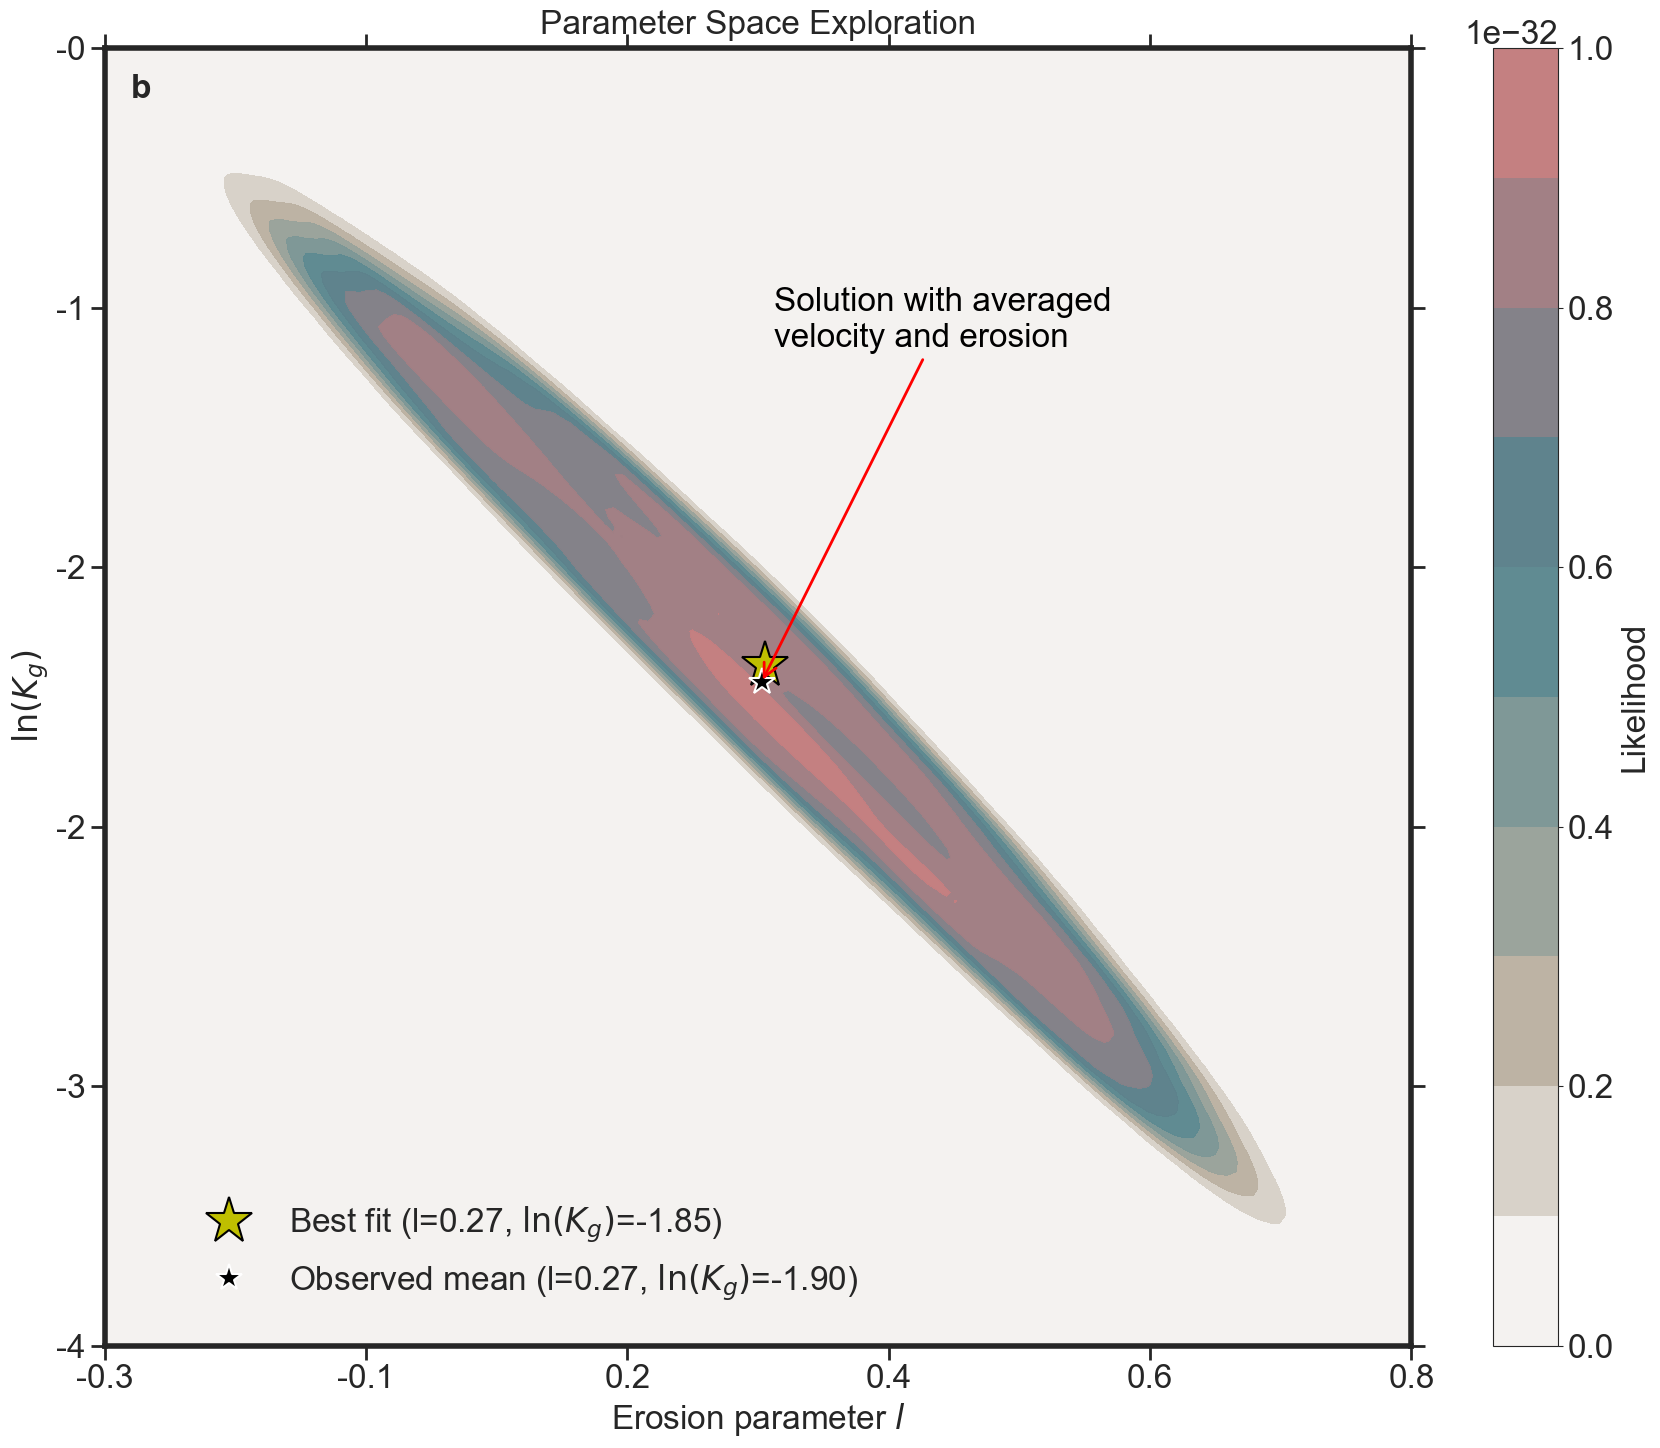

  - Subplot B complete! 'TP_Table0926' parameter trade-off plot saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Subplot_B_Only_TP_Table0926.png
  - Nonlinear least squares model R² = 0.670
  - Parameter mean point: l = 0.270, ln(K) = -1.900, K = 0.150

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926        0.273       0.1574        0.6695       27

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\BRanwu_Nonlinear_Analysis_Summary.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24  # Font size changed to 24
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 1.0  # Keep top N% with highest likelihood (changed from 2.0% to 1.0%)

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.60, 1.5]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function - Only Subplot B (Increased Center Density)

# %%
def plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate only subplot B: Parameter trade-off plot (increased center density)"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters - use stricter threshold to obtain more concentrated parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Using 2% threshold.")
        likelihood_threshold = np.percentile(likelihood_per_model, 98.0)
        accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure - only show subplot B, enlarge 1.5 times
    enlarged_figsize = (12 * 1.5, 10 * 1.5)  # Enlarge 1.5 times
    fig, ax = plt.subplots(1, 1, figsize=enlarged_figsize)
    
    # Figure B: Parameter trade-off plot (using natural logarithm)
    # Set tick marks - show tick marks on all four sides
    ax.tick_params(axis='both', which='major', 
                  direction='out',  # Tick mark direction outward
                  top=True, right=True, bottom=True, left=True,  # Show ticks on all four sides
                  length=10, width=2,  # Tick mark length and width
                  labelsize=24)  # Tick label size
    
    # Set minor tick marks
    ax.tick_params(axis='both', which='minor',
                  direction='out',
                  top=True, right=True, bottom=True, left=True,
                  length=6, width=1.5)  # Minor tick marks slightly shorter

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(4)  # Set border line thickness
        
    # Increase the display range of density plots - use larger vmax_value
    vmax_value = 1e-32  # Increased from 8e-33 to 1e-32
    
    # Create custom color map: set color gradient according to specified ranges
    # white: 0-2.5e-33, #BAB0A0: 2.5e-33-6e-33, #4D838E: 6e-33-9e-33, #D57D7E: 9e-33-1e-32
    colors = ['white', '#BAB0A0', '#4D838E', '#D57D7E']
    
    # Create color map nodes (0, 0.25, 0.6, 1.0 corresponding to 0, 2.5e-33, 6e-33, 1e-32)
    color_nodes = [0, 2.5e-33/vmax_value, 6e-33/vmax_value, 1.0]
    
    n_bins = 100
    cmap_custom = LinearSegmentedColormap.from_list('custom_cmap', 
                                                   list(zip(color_nodes, colors)), 
                                                   N=n_bins)
    
    # Create grid for confidence band - reduce grid range to focus on parameter dense areas
    # Adjust grid range based on distribution of accepted parameters
    l_min, l_max = accepted_l.min(), accepted_l.max()
    ln_keff_min, ln_keff_max = accepted_ln_keff.min(), accepted_ln_keff.max()
    
    # Leave some space around parameters
    l_range = l_max - l_min
    ln_keff_range = ln_keff_max - ln_keff_min
    
    l_grid_min = max(l_min - 0.2 * l_range, -0.8)
    l_grid_max = min(l_max + 0.2 * l_range, 1.8)
    ln_keff_grid_min = max(ln_keff_min - 0.2 * ln_keff_range, np.log(KEFF_RANGE[0]))
    ln_keff_grid_max = min(ln_keff_max + 0.2 * ln_keff_range, np.log(KEFF_RANGE[1]))
    
    # Create denser grid
    l_grid = np.linspace(l_grid_min, l_grid_max, 150)  # Increased from 100 to 150
    ln_keff_grid = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 150)  # Increased from 100 to 150
    L_grid, LN_Keff_grid = np.meshgrid(l_grid, ln_keff_grid)
    
    # Calculate likelihood values on grid points (using KDE estimation)
    from scipy.stats import gaussian_kde
    
    # Create KDE using accepted high likelihood parameters - reduce bandwidth to obtain more concentrated density
    accepted_data = np.vstack([accepted_l, accepted_ln_keff])
    
    # Calculate using Scott's rule, then reduce to obtain more concentrated distribution
    n_points = accepted_data.shape[1]
    scott_factor = n_points ** (-1./(accepted_data.shape[0] + 4))
    
    # Reduce bandwidth factor to obtain more concentrated density
    bandwidth_factor = 1  # Reduce bandwidth factor from default 1.0 to 0.5
    kde = gaussian_kde(accepted_data, bw_method=scott_factor * bandwidth_factor)
    
    # Calculate probability density on grid
    grid_points = np.vstack([L_grid.ravel(), LN_Keff_grid.ravel()])
    density = kde(grid_points).reshape(L_grid.shape)
    
    # Normalize probability density to [0, vmax_value] range
    density_normalized = density / density.max() * vmax_value
    
    # Plot confidence band - use more levels to achieve smoother transition
    contour = ax.contourf(L_grid, LN_Keff_grid, density_normalized, 
                         levels=10, cmap=cmap_custom,  # Keep 10 levels
                         vmin=0, vmax=vmax_value, alpha=0.99)  # Increase transparency
    
    # Mark nonlinear least squares best fit point
    ax.plot(l_best_fit, ln_keff_best_fit, 'y*', markersize=35, 
            markeredgecolor='black', markeredgewidth=1.5,
            label=f'Best fit (l={l_best_fit:.2f}, $\ln(K_g)$={ln_keff_best_fit:.2f})')
    
    # Use average of accepted parameters as mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    
    # Mark data mean point
    ax.plot(l_mean, ln_keff_mean, 'k*', markersize=20, 
            markeredgecolor='white', markeredgewidth=1.5,
            label=f'Observed mean (l={l_mean:.2f}, $\ln(K_g)$={ln_keff_mean:.2f})')
    
    # Add text annotation
    ax.annotate('Solution with averaged\nvelocity and erosion', xy=(l_mean, ln_keff_mean), 
                xytext=(l_mean + 0.01, ln_keff_mean + 1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=24, color='black')
    
    # Add color bar and set label
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Likelihood', fontsize=24)
    
    # Set axis labels
    ax.set_xlabel('Erosion parameter $l$', fontsize=24)
    ax.set_ylabel('$\ln(K_g)$', fontsize=24)
    
    # Use coordinate position to control legend
    legend = ax.legend(loc='lower right', bbox_to_anchor=(0.6, 0.01), 
                  frameon=False, framealpha=0.8, fontsize=24)
    
    # Set axis ranges - based on parameter distribution
    ax.set_xlim(l_grid_min, l_grid_max)
    ax.set_ylim(ln_keff_grid_min, ln_keff_grid_max)

    # Set x-axis ticks - based on actual range
    x_ticks = np.linspace(l_grid_min, l_grid_max, 6)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{x:.1f}' for x in x_ticks])

    # Set y-axis ticks - based on actual range
    y_ticks = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 6)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{y:.0f}' for y in y_ticks])

    # Ensure boundary ticks are visible
    ax.tick_params(axis='both', which='both', bottom=True, top=True, left=True, right=True)
    
    # Add subplot label
    ax.text(0.02, 0.98, 'b', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
    
    # Add title
    ax.set_title('Parameter Space Exploration', fontsize=24, pad=10)
    
    # Display parameter density information
    print(f"  - Number of accepted parameters: {len(accepted_indices)}")
    print(f"  - l parameter range: [{accepted_l.min():.3f}, {accepted_l.max():.3f}]")
    print(f"  - ln(K) parameter range: [{accepted_ln_keff.min():.3f}, {accepted_ln_keff.max():.3f}]")
    print(f"  - Maximum density value: {density.max():.3e}")
    
    # Adjust layout and save
    plt.tight_layout()
    output_file = os.path.join(output_dir, f"Subplot_B_Only_{sheet_name}.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Subplot B complete! '{sheet_name}' parameter trade-off plot saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear
    

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Only show subplot B
    best_params = plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "BRanwu_Nonlinear_Analysis_Summary.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 3 c

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 32 valid observations.
  - Year range: 1987 - 2018
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8603 -> Kg = 0.1556
    l = 0.2621
    R² = 0.7307
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.1391
    l = 0.2928
    R² = 0.7931
    Iterations: 6
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.29, K = 0.1391, ln(K) = -1.9723
  - Number of accepted parameters: 5000
  - l parameter range: [0.003, 0.722]
  - ln(K) parameter range: [-4.079, -0.759]
  - Maximum density value: 3.234e+00
  - Figure size: (18.0, 15.0)
  - Bandwidth factor: 1.0


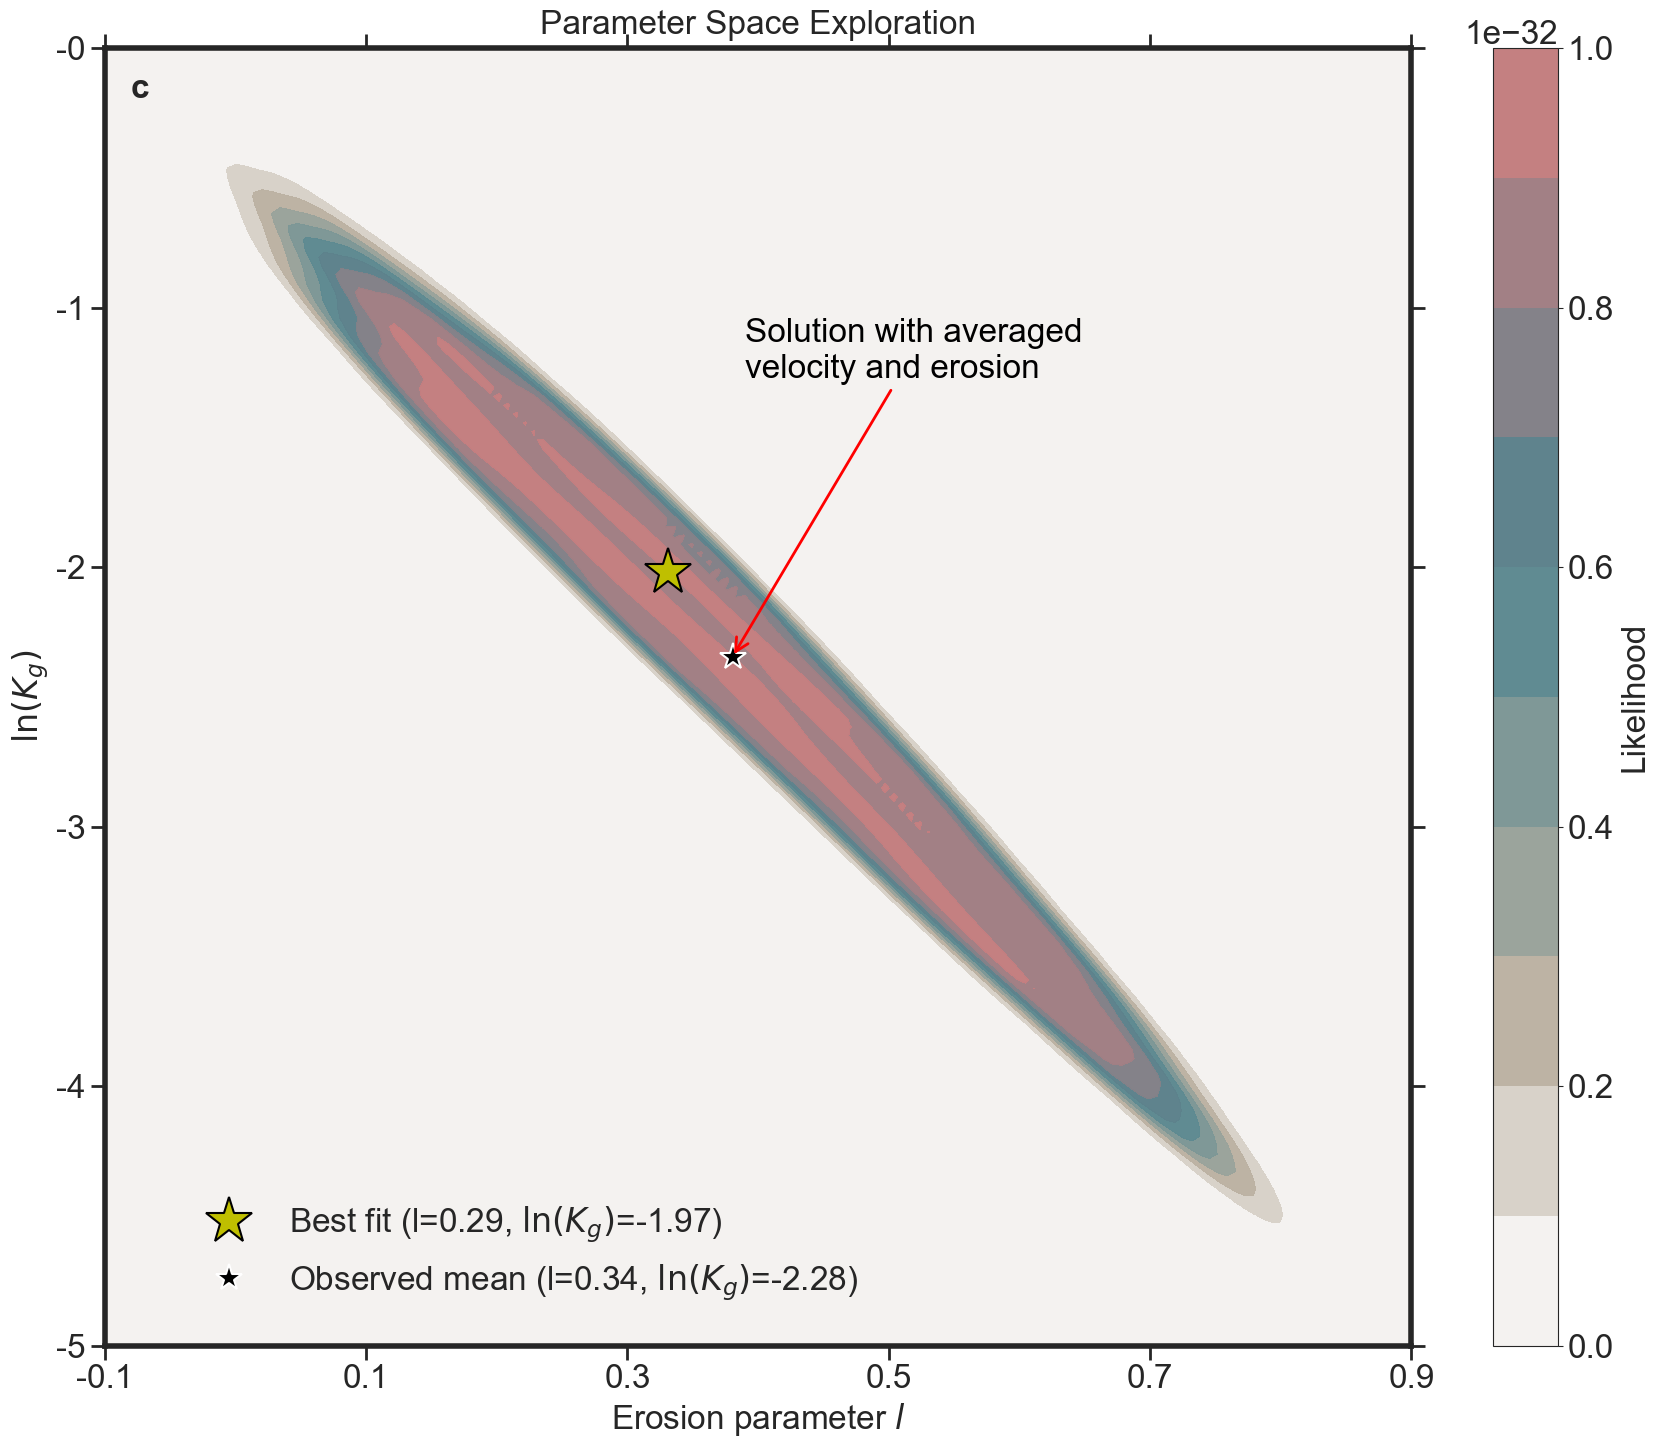

  - Subplot B complete! 'TP_Table0926' parameter trade-off plot saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Subplot_B_Only_TP_Table0926.png
  - Nonlinear least squares model R² = 0.793
  - Parameter mean point: l = 0.343, ln(K) = -2.275, K = 0.103

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.2928       0.1391        0.7931       32

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Galan_Nonlinear_Analysis_Summary.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24  # Font size changed to 24
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 1.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.50, 1.7]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Only Subplot B (Increased Center Density and Figure Size) - Galan Lake Version

# %%
def plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate only subplot B: Parameter trade-off plot (increased center density and figure size) - Galan lake version"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters - use stricter threshold to obtain more concentrated parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Using 2% threshold.")
        likelihood_threshold = np.percentile(likelihood_per_model, 98.0)
        accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure - only show subplot B, enlarge 1.5 times (consistent with Ranwu lake)
    enlarged_figsize = (12 * 1.5, 10 * 1.5)  # Enlarge 1.5 times, consistent with Ranwu lake
    fig, ax = plt.subplots(1, 1, figsize=enlarged_figsize)
    
    # Figure B: Parameter trade-off plot (using natural logarithm)
    # Set tick marks - show tick marks on all four sides
    ax.tick_params(axis='both', which='major', 
                  direction='out',  # Tick mark direction outward
                  top=True, right=True, bottom=True, left=True,  # Show ticks on all four sides
                  length=10, width=2,  # Tick mark length and width
                  labelsize=24)  # Tick label size
    
    # Set minor tick marks
    ax.tick_params(axis='both', which='minor',
                  direction='out',
                  top=True, right=True, bottom=True, left=True,
                  length=6, width=1.5)  # Minor tick marks slightly shorter

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(4)  # Set border line thickness
        
    # Increase the display range of density plots - use larger vmax_value
    vmax_value = 1e-32  # Use larger vmax_value
    
    # Create custom color map: set color gradient according to specified ranges
    # white: 0-2.5e-33, #BAB0A0: 2.5e-33-6e-33, #4D838E: 6e-33-9e-33, #D57D7E: 9e-33-1e-32
    colors = ['white', '#BAB0A0', '#4D838E', '#D57D7E']
    
    # Create color map nodes (0, 0.25, 0.6, 1.0 corresponding to 0, 2.5e-33, 6e-33, 1e-32)
    color_nodes = [0, 2.5e-33/vmax_value, 6e-33/vmax_value, 1.0]
    
    n_bins = 100
    cmap_custom = LinearSegmentedColormap.from_list('custom_cmap', 
                                                   list(zip(color_nodes, colors)), 
                                                   N=n_bins)
    
    # Create grid for confidence band - use same parameters as Ranwu lake
    l_min, l_max = accepted_l.min(), accepted_l.max()
    ln_keff_min, ln_keff_max = accepted_ln_keff.min(), accepted_ln_keff.max()
    
    # Leave some space around parameters
    l_range = l_max - l_min
    ln_keff_range = ln_keff_max - ln_keff_min
    
    # Use same boundary settings as Ranwu lake
    l_grid_min = max(l_min - 0.2 * l_range, -0.8)  # Use fixed boundaries
    l_grid_max = min(l_max + 0.2 * l_range, 1.8)   # Use fixed boundaries
    ln_keff_grid_min = max(ln_keff_min - 0.2 * ln_keff_range, np.log(KEFF_RANGE[0]))
    ln_keff_grid_max = min(ln_keff_max + 0.2 * ln_keff_range, np.log(KEFF_RANGE[1]))
    
    # Create denser grid
    l_grid = np.linspace(l_grid_min, l_grid_max, 150)  # Increased from 100 to 150
    ln_keff_grid = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 150)  # Increased from 100 to 150
    L_grid, LN_Keff_grid = np.meshgrid(l_grid, ln_keff_grid)
    
    # Create KDE using accepted high likelihood parameters - use larger bandwidth factor to obtain more dispersed density
    accepted_data = np.vstack([accepted_l, accepted_ln_keff])
    
    # Calculate using Scott's rule, then use larger bandwidth factor
    n_points = accepted_data.shape[1]
    scott_factor = n_points ** (-1./(accepted_data.shape[0] + 4))
    
    # Increase bandwidth factor to obtain more dispersed density (consistent with Ranwu lake)
    bandwidth_factor = 1.0  # Increase bandwidth factor from 0.5 to 1.0
    kde = gaussian_kde(accepted_data, bw_method=scott_factor * bandwidth_factor)
    
    # Calculate probability density on grid
    grid_points = np.vstack([L_grid.ravel(), LN_Keff_grid.ravel()])
    density = kde(grid_points).reshape(L_grid.shape)
    
    # Normalize probability density to [0, vmax_value] range
    density_normalized = density / density.max() * vmax_value
    
    # Plot confidence band - use more levels to achieve smoother transition
    contour = ax.contourf(L_grid, LN_Keff_grid, density_normalized, 
                         levels=10, cmap=cmap_custom,  # Keep 10 levels
                         vmin=0, vmax=vmax_value, alpha=0.99)  # Increase transparency to 0.99
    
    # Mark nonlinear least squares best fit point - using yellow star
    ax.plot(l_best_fit, ln_keff_best_fit, 'y*', markersize=35, 
            markeredgecolor='black', markeredgewidth=1.5,
            label=f'Best fit (l={l_best_fit:.2f}, $\ln(K_g)$={ln_keff_best_fit:.2f})')
    
    # Use average of accepted parameters as mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    
    # Mark data mean point - using black star
    ax.plot(l_mean, ln_keff_mean, 'k*', markersize=20, 
            markeredgecolor='white', markeredgewidth=1.5,
            label=f'Observed mean (l={l_mean:.2f}, $\ln(K_g)$={ln_keff_mean:.2f})')
    
    # Add text annotation
    ax.annotate('Solution with averaged\nvelocity and erosion', xy=(l_mean, ln_keff_mean), 
                xytext=(l_mean + 0.01, ln_keff_mean + 1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=24, color='black')
    
    # Add color bar and set label
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Likelihood', fontsize=24)
    
    # Set axis labels
    ax.set_xlabel('Erosion parameter $l$', fontsize=24)
    ax.set_ylabel('$\ln(K_g)$', fontsize=24)
    
    # Use coordinate position to control legend
    legend = ax.legend(loc='lower right', bbox_to_anchor=(0.6, 0.01),  # Adjust legend position
                  frameon=False, framealpha=0.8, fontsize=24)
    
    # Set axis ranges - use same range settings as Ranwu lake
    ax.set_xlim(l_grid_min, l_grid_max)
    ax.set_ylim(ln_keff_grid_min, ln_keff_grid_max)

    # Set x-axis ticks - based on actual range
    x_ticks = np.linspace(l_grid_min, l_grid_max, 6)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{x:.1f}' for x in x_ticks], fontsize=24)

    # Set y-axis ticks - based on actual range
    y_ticks = np.linspace(ln_keff_grid_min, ln_keff_grid_max, 6)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{y:.0f}' for y in y_ticks], fontsize=24)

    # Ensure boundary ticks are visible
    ax.tick_params(axis='both', which='both', bottom=True, top=True, left=True, right=True)
    
    # Add subplot label - changed to (c) because this is the third lake
    ax.text(0.02, 0.98, 'c', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
    
    # Add title
    ax.set_title('Parameter Space Exploration', fontsize=24, pad=10)
    
    # Display parameter density information
    print(f"  - Number of accepted parameters: {len(accepted_indices)}")
    print(f"  - l parameter range: [{accepted_l.min():.3f}, {accepted_l.max():.3f}]")
    print(f"  - ln(K) parameter range: [{accepted_ln_keff.min():.3f}, {accepted_ln_keff.max():.3f}]")
    print(f"  - Maximum density value: {density.max():.3e}")
    print(f"  - Figure size: {enlarged_figsize}")
    print(f"  - Bandwidth factor: {bandwidth_factor}")
    
    # Adjust layout and save
    plt.tight_layout()
    output_file = os.path.join(output_dir, f"Subplot_B_Only_{sheet_name}.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Subplot B complete! '{sheet_name}' parameter trade-off plot saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Only show subplot B
    best_params = plot_single_subplot_B(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Galan_Nonlinear_Analysis_Summary.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 3 d&g

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 21 valid observations.
  - Year range: 1990 - 2022
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -3.0144 -> Kg = 0.0491
    l = 0.5553
    R² = 0.7931
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.0540
    l = 0.5219
    R² = 0.7921
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.52, K = 0.0540, ln(K) = -2.9186


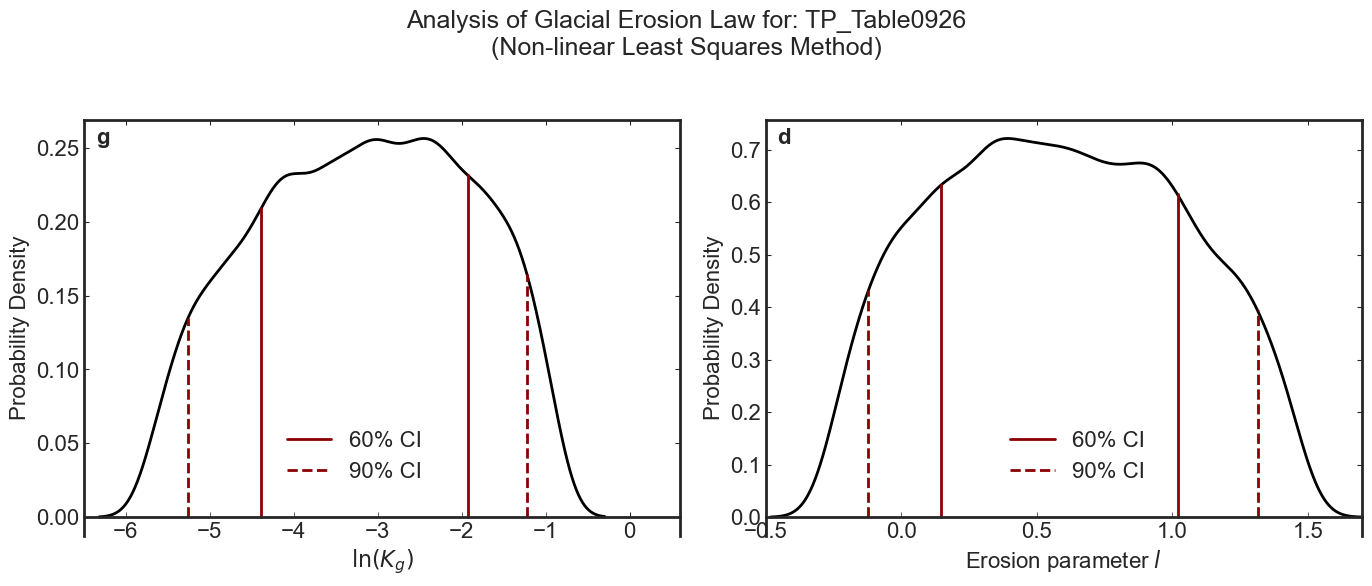

  - Analysis complete! 'TP_Table0926' C and D plots saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Nonlinear_Analysis_TP_Table0926_CD_only.png
  - Nonlinear least squares model R² = 0.792
  - Parameter mean point: l = 0.586, ln(K) = -3.168, K = 0.042

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.5219        0.054        0.7921       21

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Aksayqin_Nonlinear_Analysis_Summary_CD_only.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-4, 1e2]  # Range of Keff
L_RANGE = [-0.90, 2.25]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only C and D Plots)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only C and D plots)"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create figure - only keep C and D plots, using 1x2 layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Analysis of Glacial Erosion Law for: {sheet_name}\n(Non-linear Least Squares Method)', 
                 fontsize=18, y=0.98)
    
    # Plot C: K distribution (using natural logarithm) - placed on left
    ax = axes[0]
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value

    # Calculate probability density curve using KDE
    kde_ln_keff = gaussian_kde(accepted_ln_keff)
    # Extend x-axis range to connect curve to x-axis
    x_min_ln_keff = min(accepted_ln_keff) - 0.5  # Extend left
    x_max_ln_keff = max(accepted_ln_keff) + 0.5  # Extend right
    x_ln_keff = np.linspace(x_min_ln_keff, x_max_ln_keff, 1000)
    y_ln_keff = kde_ln_keff(x_ln_keff)

    # Connect curve to x-axis: add y=0 points at start and end
    x_ln_keff_full = np.concatenate([[x_min_ln_keff], x_ln_keff, [x_max_ln_keff]])
    y_ln_keff_full = np.concatenate([[0], y_ln_keff, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_ln_keff_full, 0, y_ln_keff_full, color='white', alpha=0.3)
    ax.plot(x_ln_keff_full, y_ln_keff_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_ln_keff, [20, 80])
    ci_90 = np.percentile(accepted_ln_keff, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_ln_keff_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_ln_keff_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_ln_keff_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_ln_keff_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_ln_keff_full[idx_60_0]], color='darkred', linestyle='-', linewidth=2)
    ax.plot([ci_60[1], ci_60[1]], [0, y_ln_keff_full[idx_60_1]], color='darkred', linestyle='-', linewidth=2, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_ln_keff_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_ln_keff_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-6.5, 0.6)

    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('$\ln(K_g)$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)

    # Legend position
    ax.legend(loc='upper right', bbox_to_anchor=(0.6, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'g', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

    # Plot D: l distribution - placed on right
    ax = axes[1]
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate probability density curve using KDE
    kde_l = gaussian_kde(accepted_l)
    # Extend x-axis range to connect curve to x-axis
    x_min_l = min(accepted_l) - 0.2  # Extend left
    x_max_l = max(accepted_l) + 0.2  # Extend right
    x_l = np.linspace(x_min_l, x_max_l, 1000)
    y_l = kde_l(x_l)

    # Connect curve to x-axis: add y=0 points at start and end
    x_l_full = np.concatenate([[x_min_l], x_l, [x_max_l]])
    y_l_full = np.concatenate([[0], y_l, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_l_full, 0, y_l_full, color='white', alpha=0.3)
    ax.plot(x_l_full, y_l_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_l, [20, 80])
    ci_90 = np.percentile(accepted_l, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_l_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_l_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_l_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_l_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_l_full[idx_60_0]], color='darkred', linestyle='-', linewidth=2)
    ax.plot([ci_60[1], ci_60[1]], [0, y_l_full[idx_60_1]], color='darkred', linestyle='-', linewidth=2, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_l_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_l_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-0.5, 1.7)

    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('Erosion parameter $l$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)

    # Legend position
    ax.legend(loc='upper right', bbox_to_anchor=(0.67, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'd', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_CD_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' C and D plots saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    
    # Calculate parameter mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only C and D plots)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Aksayqin_Nonlinear_Analysis_Summary_CD_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 3e&h

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 27 valid observations.
  - Year range: 1987 - 2013
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8956 -> Kg = 0.1502
    l = 0.2833
    R² = 0.5969
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.1574
    l = 0.2730
    R² = 0.6695
    Iterations: 4
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.27, K = 0.1574, ln(K) = -1.8488


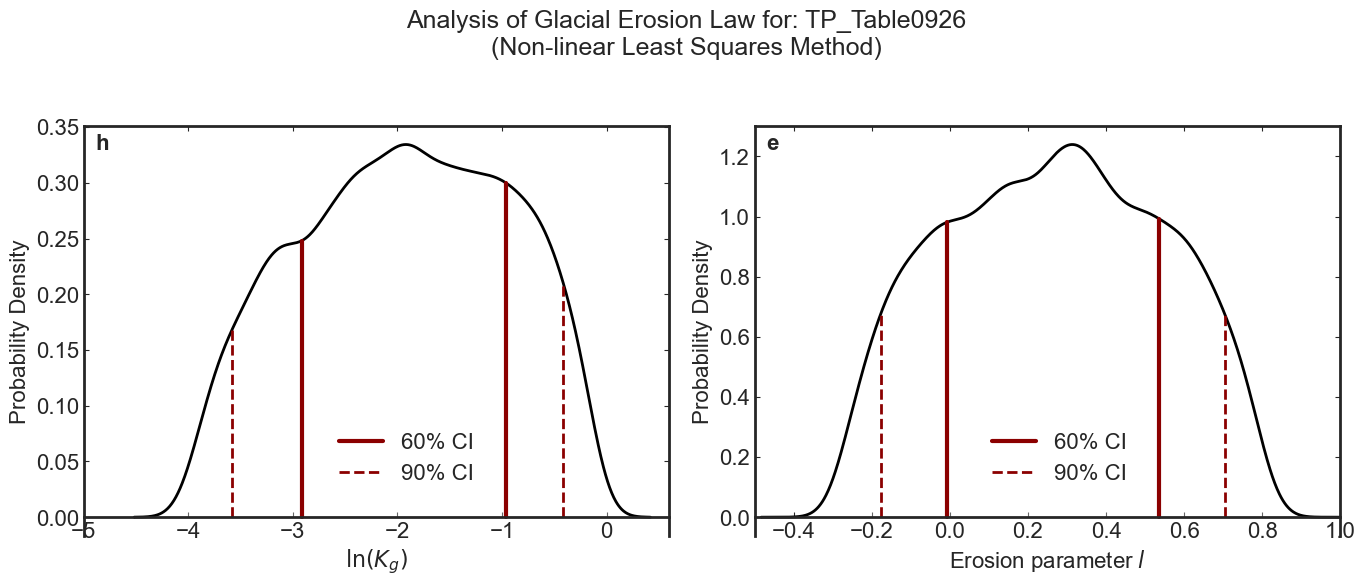

  - Analysis complete! 'TP_Table0926' C and D plots saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Nonlinear_Analysis_TP_Table0926_CD_only.png
  - Nonlinear least squares model R² = 0.670
  - Parameter mean point: l = 0.266, ln(K) = -1.939, K = 0.144

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926        0.273       0.1574        0.6695       27

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Ranwu_Nonlinear_Analysis_Summary_CD_only.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde  # Add this import

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.60, 1.5]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only C and D Plots)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only C and D plots)"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create figure - only keep C and D plots, using 1x2 layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Analysis of Glacial Erosion Law for: {sheet_name}\n(Non-linear Least Squares Method)', 
                 fontsize=18, y=0.98)
    
    # Plot C: K distribution (using natural logarithm) - placed on left
    ax = axes[0]
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
    
    # Calculate probability density curve using KDE
    kde_ln_keff = gaussian_kde(accepted_ln_keff)
    # Extend x-axis range to connect curve to x-axis
    x_min_ln_keff = min(accepted_ln_keff) - 0.5  # Extend left
    x_max_ln_keff = max(accepted_ln_keff) + 0.5  # Extend right
    x_ln_keff = np.linspace(x_min_ln_keff, x_max_ln_keff, 1000)
    y_ln_keff = kde_ln_keff(x_ln_keff)

    # Connect curve to x-axis: add y=0 points at start and end
    x_ln_keff_full = np.concatenate([[x_min_ln_keff], x_ln_keff, [x_max_ln_keff]])
    y_ln_keff_full = np.concatenate([[0], y_ln_keff, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_ln_keff_full, 0, y_ln_keff_full, color='white', alpha=0.3)
    ax.plot(x_ln_keff_full, y_ln_keff_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_ln_keff, [20, 80])
    ci_90 = np.percentile(accepted_ln_keff, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_ln_keff_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_ln_keff_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_ln_keff_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_ln_keff_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_ln_keff_full[idx_60_0]], color='darkred', linestyle='-', linewidth=3)
    ax.plot([ci_60[1], ci_60[1]], [0, y_ln_keff_full[idx_60_1]], color='darkred', linestyle='-', linewidth=3, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_ln_keff_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_ln_keff_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-5, 0.6)
    
    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('$\ln(K_g)$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)

    # Legend position
    ax.legend(loc='upper right', bbox_to_anchor=(0.7, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'h', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

    # Plot D: l distribution - placed on right
    ax = axes[1]
    
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate probability density curve using KDE
    kde_l = gaussian_kde(accepted_l)
    # Extend x-axis range to connect curve to x-axis
    x_min_l = min(accepted_l) - 0.2  # Extend left
    x_max_l = max(accepted_l) + 0.2  # Extend right
    x_l = np.linspace(x_min_l, x_max_l, 1000)
    y_l = kde_l(x_l)

    # Connect curve to x-axis: add y=0 points at start and end
    x_l_full = np.concatenate([[x_min_l], x_l, [x_max_l]])
    y_l_full = np.concatenate([[0], y_l, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_l_full, 0, y_l_full, color='white', alpha=0.3)
    ax.plot(x_l_full, y_l_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_l, [20, 80])
    ci_90 = np.percentile(accepted_l, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_l_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_l_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_l_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_l_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_l_full[idx_60_0]], color='darkred', linestyle='-', linewidth=3)
    ax.plot([ci_60[1], ci_60[1]], [0, y_l_full[idx_60_1]], color='darkred', linestyle='-', linewidth=3, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_l_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_l_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-0.5, 1)
    
    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('Erosion parameter $l$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)

    # Legend position
    ax.legend(loc='upper right', bbox_to_anchor=(0.67, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'e', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_CD_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' C and D plots saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    
    # Calculate parameter mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only C and D plots)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Ranwu_Nonlinear_Analysis_Summary_CD_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure 3 f&i

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 32 valid observations.
  - Year range: 1987 - 2018
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8603 -> Kg = 0.1556
    l = 0.2621
    R² = 0.7307
    p-value = 0.0000
  - Performing nonlinear least squares fitting...
  - Nonlinear least squares fitting results:
    K = 0.1391
    l = 0.2928
    R² = 0.7931
    Iterations: 6
  - Calculating parameter space...
  - 'TP_Table0926' nonlinear least squares best fit model: l = 0.29, K = 0.1391, ln(K) = -1.9723


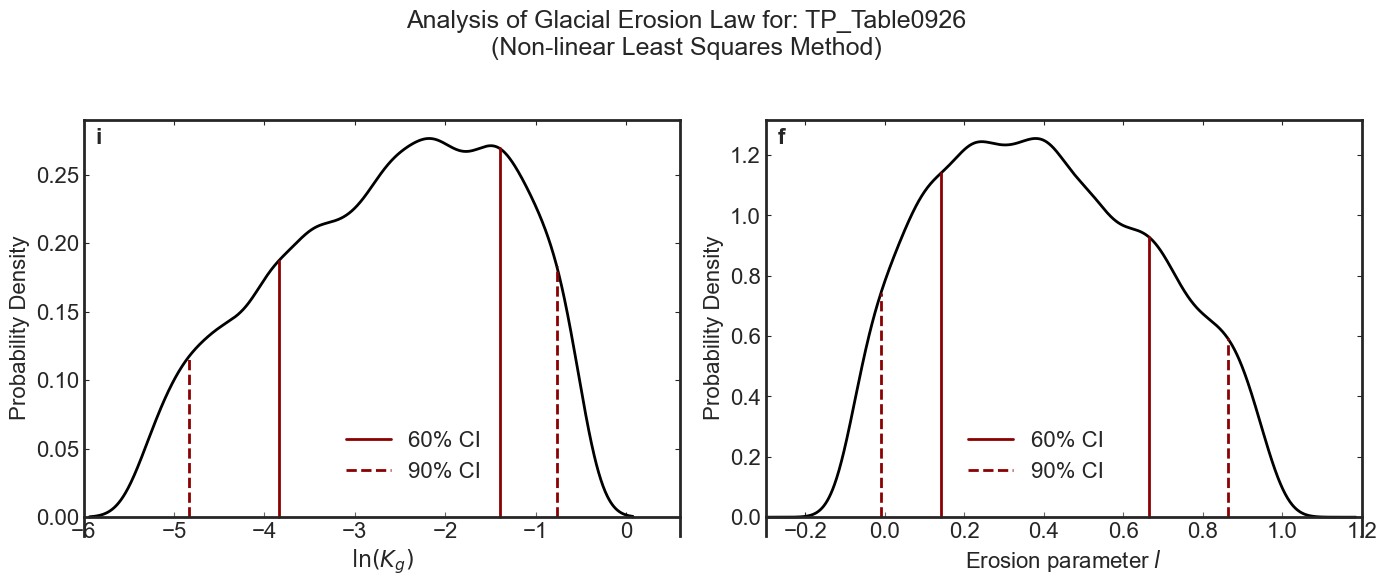

  - Analysis complete! 'TP_Table0926' C and D plots saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Nonlinear_Analysis_TP_Table0926_CD_only.png
  - Nonlinear least squares model R² = 0.793
  - Parameter mean point: l = 0.402, ln(K) = -2.617, K = 0.073

Analysis Results Summary:
          Sheet  Nonlinear_l  Nonlinear_K  Nonlinear_R2  Num_obs
0  TP_Table0926       0.2928       0.1391        0.7931       32

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Nonlinear_Analysis_Summary_CD_only.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde  # Add this import

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.50, 1.7]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Nonlinear Least Squares Fitting Function

# %%
def nonlinear_least_squares_fit(gv_obs, ssy_obs):
    """Use nonlinear least squares to fit power law model"""
    
    def power_law(params, x):
        """Power law model: y = K * x^l"""
        K, l = params
        return K * (x ** l)
    
    def residuals(params, x, y):
        """Residual function"""
        return power_law(params, x) - y
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    initial_guess = [np.exp(intercept), slope]
    
    # Parameter bounds
    bounds = ([KEFF_RANGE[0], L_RANGE[0]], [KEFF_RANGE[1], L_RANGE[1]])
    
    try:
        # Nonlinear least squares fitting
        result = optimize.least_squares(residuals, initial_guess, args=(gv_obs, ssy_obs), 
                                      bounds=bounds, method='trf')
        
        if result.success:
            K_opt, l_opt = result.x
            # Calculate R²
            predicted = power_law(result.x, gv_obs)
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Nonlinear least squares fitting results:")
            print(f"    K = {K_opt:.4f}")
            print(f"    l = {l_opt:.4f}")
            print(f"    R² = {r_squared:.4f}")
            print(f"    Iterations: {result.nfev}")
            
            return {
                'K': K_opt,
                'l': l_opt,
                'ln_K': np.log(K_opt),
                'R_squared': r_squared,
                'success': True,
                'nfev': result.nfev
            }
        else:
            print(f"  - Nonlinear least squares fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Nonlinear least squares fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    likelihood_per_model = np.exp(-0.5 * rss_per_model / np.var(ssy_obs))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only C and D Plots)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results):
    """Generate result visualization (only C and D plots)"""
    
    # Get best fit parameters from nonlinear least squares
    if nonlinear_results['success']:
        l_best_fit = nonlinear_results['l']
        keff_best_fit = nonlinear_results['K']
        ln_keff_best_fit = nonlinear_results['ln_K']
        r_squared_nonlinear = nonlinear_results['R_squared']
    else:
        # If nonlinear fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_nonlinear = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' nonlinear least squares best fit model: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create figure - only keep C and D plots, using 1x2 layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Analysis of Glacial Erosion Law for: {sheet_name}\n(Non-linear Least Squares Method)', 
                 fontsize=18, y=0.98)
    
    # Plot C: K distribution (using natural logarithm) - placed on left
    ax = axes[0]

    # Add inward ticks - show ticks on all four sides
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value

    # Calculate probability density curve using KDE
    kde_ln_keff = gaussian_kde(accepted_ln_keff)
    # Extend x-axis range to connect curve to x-axis
    x_min_ln_keff = min(accepted_ln_keff) - 0.5  # Extend left
    x_max_ln_keff = max(accepted_ln_keff) + 0.5  # Extend right
    x_ln_keff = np.linspace(x_min_ln_keff, x_max_ln_keff, 1000)
    y_ln_keff = kde_ln_keff(x_ln_keff)

    # Connect curve to x-axis: add y=0 points at start and end
    x_ln_keff_full = np.concatenate([[x_min_ln_keff], x_ln_keff, [x_max_ln_keff]])
    y_ln_keff_full = np.concatenate([[0], y_ln_keff, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_ln_keff_full, 0, y_ln_keff_full, color='white', alpha=0.3)
    ax.plot(x_ln_keff_full, y_ln_keff_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_ln_keff, [20, 80])
    ci_90 = np.percentile(accepted_ln_keff, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_ln_keff_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_ln_keff_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_ln_keff_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_ln_keff_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_ln_keff_full[idx_60_0]], color='darkred', linestyle='-', linewidth=2)
    ax.plot([ci_60[1], ci_60[1]], [0, y_ln_keff_full[idx_60_1]], color='darkred', linestyle='-', linewidth=2, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_ln_keff_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_ln_keff_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-6, 0.6)
    
    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('$\ln(K_g)$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)
    
    # Legend position - editable position
    ax.legend(loc='upper right', bbox_to_anchor=(0.7, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'i', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')
    
    # Plot D: l distribution - placed on right
    ax = axes[1]

    # Add inward ticks - show ticks on all four sides
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate probability density curve using KDE
    kde_l = gaussian_kde(accepted_l)
    # Extend x-axis range to connect curve to x-axis
    x_min_l = min(accepted_l) - 0.2  # Extend left
    x_max_l = max(accepted_l) + 0.2  # Extend right
    x_l = np.linspace(x_min_l, x_max_l, 1000)
    y_l = kde_l(x_l)

    # Connect curve to x-axis: add y=0 points at start and end
    x_l_full = np.concatenate([[x_min_l], x_l, [x_max_l]])
    y_l_full = np.concatenate([[0], y_l, [0]])

    # Plot filled KDE curve (connected to x-axis)
    ax.fill_between(x_l_full, 0, y_l_full, color='white', alpha=0.3)
    ax.plot(x_l_full, y_l_full, color='black', linewidth=2)

    # Calculate confidence intervals
    ci_60 = np.percentile(accepted_l, [20, 80])
    ci_90 = np.percentile(accepted_l, [5, 95])

    # Find density values corresponding to confidence intervals
    idx_60_0 = np.abs(x_l_full - ci_60[0]).argmin()
    idx_60_1 = np.abs(x_l_full - ci_60[1]).argmin()
    idx_90_0 = np.abs(x_l_full - ci_90[0]).argmin()
    idx_90_1 = np.abs(x_l_full - ci_90[1]).argmin()

    # Draw confidence interval lines connected to curve (using dark red)
    # 60% CI - solid line
    ax.plot([ci_60[0], ci_60[0]], [0, y_l_full[idx_60_0]], color='darkred', linestyle='-', linewidth=2)
    ax.plot([ci_60[1], ci_60[1]], [0, y_l_full[idx_60_1]], color='darkred', linestyle='-', linewidth=2, label='60% CI')

    # 90% CI - dashed line
    ax.plot([ci_90[0], ci_90[0]], [0, y_l_full[idx_90_0]], color='darkred', linestyle='--', linewidth=2)
    ax.plot([ci_90[1], ci_90[1]], [0, y_l_full[idx_90_1]], color='darkred', linestyle='--', linewidth=2, label='90% CI')

    # Set x-axis range
    ax.set_xlim(-0.3, 1.2)
    
    # Move x-axis to y=0 position
    ax.spines['bottom'].set_position('zero')

    ax.set_xlabel('Erosion parameter $l$', fontsize=16)
    ax.set_ylabel('Probability Density', fontsize=16)
    
    # Legend position - editable position
    ax.legend(loc='upper right', bbox_to_anchor=(0.6, 0.3), 
              frameon=False, framealpha=0.9, fontsize=16)
    ax.text(0.02, 0.98, 'f', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Nonlinear_Analysis_{sheet_name}_CD_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' C and D plots saved to: {output_file}")
    print(f"  - Nonlinear least squares model R² = {r_squared_nonlinear:.3f}")
    
    # Calculate parameter mean point
    l_mean = np.mean(accepted_l)
    ln_keff_mean = np.mean(accepted_ln_keff)
    keff_mean = np.exp(ln_keff_mean)
    print(f"  - Parameter mean point: l = {l_mean:.3f}, ln(K) = {ln_keff_mean:.3f}, K = {keff_mean:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_nonlinear

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform nonlinear least squares fitting
    print(f"  - Performing nonlinear least squares fitting...")
    nonlinear_results = nonlinear_least_squares_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only C and D plots)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, nonlinear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Nonlinear_l': best_params[0],
            'Nonlinear_K': best_params[1],
            'Nonlinear_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Nonlinear_Analysis_Summary_CD_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

##  Figure S5: Constraining the velocity-erosion rule（Bayesian‑inferred）

### Figure S5a (Bayesian‑inferred)

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 21 valid observations.
  - Year range: 1990 - 2022
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -3.0144 -> Kg = 0.0491
    l = 0.5553
    R² = 0.7931
    p-value = 0.0000
  - Performing Bayesian model fitting...
  - Bayesian model fitting results (Maximum a posteriori estimate):
    K = 0.0539
    l = 0.5237
    sigma = 0.0306
    R² = 0.7920
  - Calculating parameter space...
  - 'TP_Table0926' Bayesian model best fit: l = 0.52, K = 0.0539, ln(K) = -2.9210


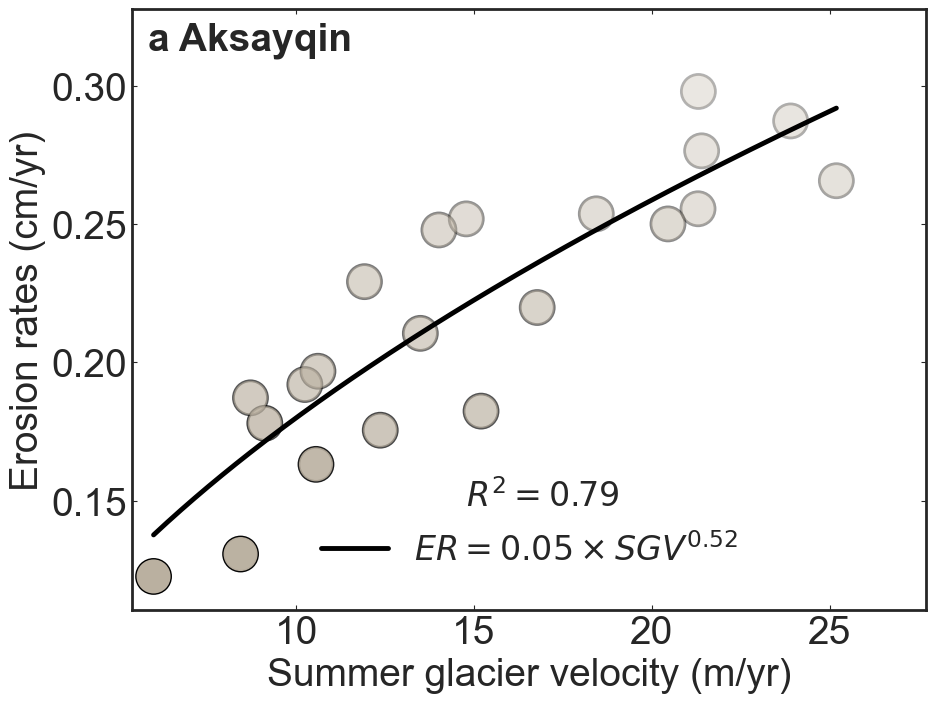

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Bayesian_Analysis_TP_Table0926_A_only.png
  - Bayesian model R² = 0.792

Analysis Results Summary:
          Sheet  Bayesian_l  Bayesian_K  Bayesian_R2  Num_obs
0  TP_Table0926      0.5237      0.0539        0.792       21

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake\Aksayqin_Bayesian_Analysis_Summary_A_only.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import optimize
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28  # Font size changed to 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Aksayqin lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-4, 1e2]  # Range of Keff
L_RANGE = [-0.90, 2.25]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Bayesian Model Fitting Function

# %%
def bayesian_model_fit(gv_obs, ssy_obs):
    """Use Bayesian method to fit power law model"""
    
    def power_law(K, l, x):
        """Power law model: y = K * x^l"""
        return K * (x ** l)
    
    def log_likelihood(params, x, y):
        """Log-likelihood function - assuming Gaussian noise"""
        K, l, sigma = params
        y_pred = power_law(K, l, x)
        n = len(y)
        log_lik = -n/2 * np.log(2 * np.pi * sigma**2) - np.sum((y - y_pred)**2) / (2 * sigma**2)
        return log_lik
    
    def log_prior(params):
        """Log-prior distribution"""
        K, l, sigma = params
        # Prior for K - log-uniform distribution
        if not (KEFF_RANGE[0] <= K <= KEFF_RANGE[1]):
            return -np.inf
        # Prior for l - uniform distribution
        if not (L_RANGE[0] <= l <= L_RANGE[1]):
            return -np.inf
        # Prior for sigma - Jeffreys prior (1/sigma)
        if sigma <= 0:
            return -np.inf
        return -np.log(sigma)
    
    def log_posterior(params, x, y):
        """Log-posterior distribution"""
        lp = log_prior(params)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(params, x, y)
    
    # Initial guess values (using linear regression results)
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    slope, intercept = stats.linregress(ln_gv, ln_sed)[:2]
    
    # Initial parameter guesses
    K_init = np.exp(intercept)
    l_init = slope
    sigma_init = np.std(ssy_obs) * 0.1  # Initial noise estimate
    
    initial_guess = [K_init, l_init, sigma_init]
    
    # Use MCMC sampling (simplified version - use optimization to find maximum a posteriori estimate)
    try:
        # Maximize posterior probability
        def neg_log_posterior(params):
            return -log_posterior(params, gv_obs, ssy_obs)
        
        # Parameter bounds
        bounds = [(KEFF_RANGE[0], KEFF_RANGE[1]), 
                 (L_RANGE[0], L_RANGE[1]), 
                 (1e-10, None)]
        
        result = optimize.minimize(neg_log_posterior, initial_guess, 
                                 method='L-BFGS-B', bounds=bounds)
        
        if result.success:
            K_map, l_map, sigma_map = result.x
            
            # Calculate predictions
            predicted = power_law(K_map, l_map, gv_obs)
            
            # Calculate R²
            ss_total = np.sum((ssy_obs - np.mean(ssy_obs)) ** 2)
            ss_residual = np.sum((ssy_obs - predicted) ** 2)
            r_squared = 1 - (ss_residual / ss_total)
            
            print(f"  - Bayesian model fitting results (Maximum a posteriori estimate):")
            print(f"    K = {K_map:.4f}")
            print(f"    l = {l_map:.4f}")
            print(f"    sigma = {sigma_map:.4f}")
            print(f"    R² = {r_squared:.4f}")
            
            return {
                'K': K_map,
                'l': l_map,
                'ln_K': np.log(K_map),
                'sigma': sigma_map,
                'R_squared': r_squared,
                'success': True
            }
        else:
            print(f"  - Bayesian model fitting failed: {result.message}")
            return {'success': False}
            
    except Exception as e:
        print(f"  - Bayesian model fitting error: {e}")
        return {'success': False}

# %% [markdown]
# ## 6. Parameter Sampling and Likelihood Calculation Function

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate likelihood in parameter space"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)
    
    # Calculate residuals
    residuals_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples) - ssy_obs[:, np.newaxis]
    rss_per_model = np.sum(residuals_matrix ** 2, axis=0)  # Residual sum of squares
    
    # Convert to likelihood values (smaller residuals, higher likelihood)
    # Using Gaussian likelihood function
    sigma = np.std(ssy_obs)  # Using standard deviation of observations as noise estimate
    likelihood_per_model = np.exp(-rss_per_model / (2 * sigma ** 2))
    
    return l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model

# %% [markdown]
# ## 7. Result Visualization Function (Only Figure A)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, bayesian_results):
    """Generate result visualization (only Figure A)"""
    
    # Get best fit parameters from Bayesian model
    if bayesian_results['success']:
        l_best_fit = bayesian_results['l']
        keff_best_fit = bayesian_results['K']
        ln_keff_best_fit = bayesian_results['ln_K']
        r_squared_bayesian = bayesian_results['R_squared']
    else:
        # If Bayesian fitting fails, use linear regression results
        l_best_fit = linear_results['l']
        keff_best_fit = linear_results['Kg']
        ln_keff_best_fit = linear_results['ln_Kg']
        r_squared_bayesian = linear_results['R_squared']
        print(f"  - Warning: Using linear regression results as substitute")
    
    print(f"  - '{sheet_name}' Bayesian model best fit: l = {l_best_fit:.2f}, K = {keff_best_fit:.4f}, ln(K) = {ln_keff_best_fit:.4f}")
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))  # Adjust size to accommodate large font
    
    # Figure A: Erosion rate vs. Velocity (only show Bayesian model fit)
    # Add inward ticks
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True, labelsize=28)  # Tick label font size 28
    
    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
    
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # Plot observation data points - using #BAB0A0 color, transparency based on year
    # First draw outer ring (black border)
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='none', edgecolors='black', 
               linewidths=2, s=600, alpha=alpha_values_year[i])
    # Then draw inner filled points    
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='#BAB0A0', alpha=alpha_values_year[i], s=600, edgecolors='none')
   
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-10, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot Bayesian model best fit curve (power law model)
    ssy_fit_bayesian = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_bayesian, color='black', linewidth=3.5,  # Increase line width
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Add R² annotation (only show Bayesian model R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_bayesian:.2f}$', transform=ax.transAxes, 
            fontsize=24, verticalalignment='top',  # R² font size slightly smaller
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)  # X-axis label font size 28
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)  # Y-axis label font size 28
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=24)  # Legend font size 24

    ax.set_xlim(gv_obs.min()*0.9, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'a Aksayqin', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')  # Subplot label font size 28
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Bayesian_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Bayesian model R² = {r_squared_bayesian:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_bayesian

# %% [markdown]
# ## 8. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for initial guess)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Perform Bayesian model fitting
    print(f"  - Performing Bayesian model fitting...")
    bayesian_results = bayesian_model_fit(gv_obs, ssy_obs)
    
    # Calculate parameter space likelihood
    print(f"  - Calculating parameter space...")
    l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, rss_per_model, likelihood_per_model, linear_results, bayesian_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Bayesian_l': best_params[0],
            'Bayesian_K': best_params[1],
            'Bayesian_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 9. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Aksayqin_Bayesian_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure S5b(Bayesian‑inferred)

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 27 valid observations.
  - Year range: 1987 - 2013
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8956 -> Kg = 0.1502
    l = 0.2833
    R² = 0.5969
    p-value = 0.0000
  - Performing Bayesian analysis...
  - 'TP_Table0926' Bayesian best fit model: l = 0.29, K_eff = 0.1497, ln(K_eff) = -1.8988


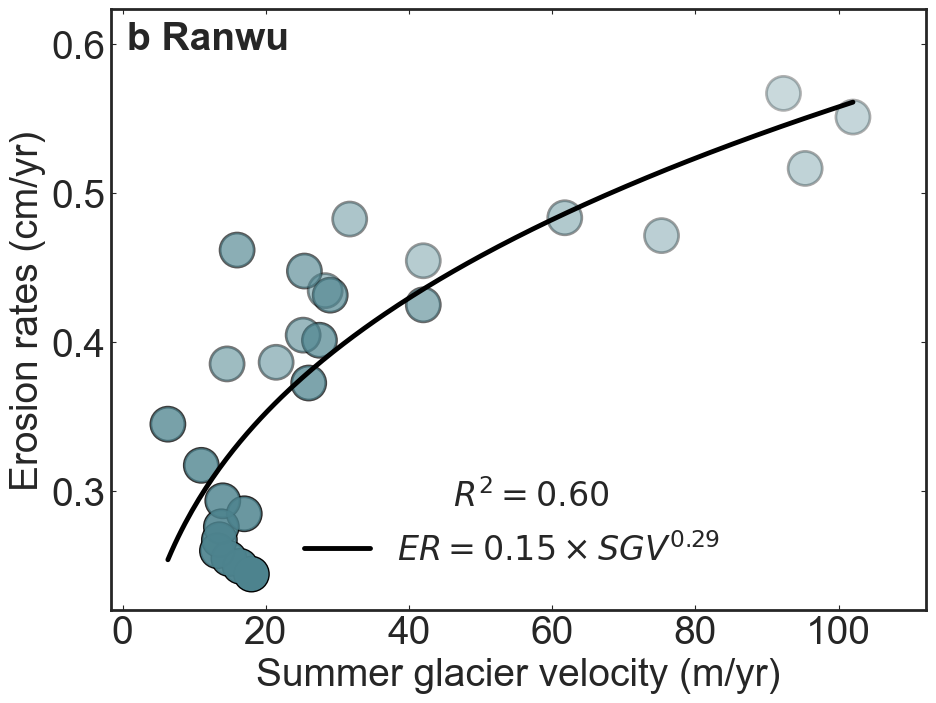

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\Bayesian_Analysis_TP_Table0926_A_only.png
  - Bayesian model R² = 0.597

Analysis Results Summary:
          Sheet  Bayesian_l  Bayesian_Keff  Bayesian_R2  Num_obs
0  TP_Table0926      0.2857         0.1497       0.5966       27

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Ranwu lake\SGV&SR_Ranwu lake_Bayesian_Analysis_Summary_A_only.csv


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28  # Font size changed to 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Ranwu lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.50, 1.5]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Parameter Sampling and Likelihood Calculation Function (Using Natural Logarithm)

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate parameter likelihood (using natural logarithm)"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)  # Exponential transform back to linear space
    
    # Calculate statistics of observations in log space (using natural logarithm)
    ln_ssy_obs = np.log(ssy_obs)
    sigma = np.std(ln_ssy_obs)
    if sigma == 0: sigma = 1e-9  # Avoid division by zero
    
    # Calculate model predictions
    predicted_ssy_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples)
    
    # Calculate sum of squared standardized residuals in log space (using natural logarithm)
    ln_predicted_ssy_matrix = np.log(predicted_ssy_matrix)
    ln_residuals = (ln_predicted_ssy_matrix - ln_ssy_obs[:, np.newaxis]) / sigma
    chi_squared_per_model = np.sum(ln_residuals ** 2, axis=0)
    
    # Calculate likelihood function values
    likelihood_per_model = np.exp(-0.5 * chi_squared_per_model)
    
    return l_samples, keff_samples, ln_keff_samples, likelihood_per_model

# %% [markdown]
# ## 6. Result Visualization Function (Only Figure A)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, likelihood_per_model, linear_results):
    """Generate result visualization (only Figure A)"""
    # Determine best fit parameters
    max_likelihood_idx = np.argmax(likelihood_per_model)
    l_best_fit = l_samples[max_likelihood_idx]
    keff_best_fit = keff_samples[max_likelihood_idx]
    ln_keff_best_fit = ln_keff_samples[max_likelihood_idx]
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    print(f"  - '{sheet_name}' Bayesian best fit model: l = {l_best_fit:.2f}, K_eff = {keff_best_fit:.4f}, ln(K_eff) = {ln_keff_best_fit:.4f}")
    
    # Calculate R² value for Bayesian model
    predicted_ssy_bayesian = keff_best_fit * (gv_obs ** l_best_fit)
    ss_total = np.sum((np.log(ssy_obs) - np.mean(np.log(ssy_obs))) ** 2)
    ss_residual_bayesian = np.sum((np.log(ssy_obs) - np.log(predicted_ssy_bayesian)) ** 2)
    r_squared_bayesian = 1 - (ss_residual_bayesian / ss_total)
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))  # Adjust size to accommodate large font
    
    # Figure A: Erosion rate vs. Velocity (only show Bayesian fit)
    # Add inward ticks - show ticks on all four sides
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True, labelsize=28)  # Tick label font size 28

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # Plot observation data points - using #4D838E color, transparency based on year
    # First draw outer ring (black border)
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='none', edgecolors='black', 
               linewidths=2, s=600, alpha=alpha_values_year[i])
    # Then draw inner filled points    
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='#4D838E', alpha=alpha_values_year[i], s=600, edgecolors='none')
   
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-9, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot Bayesian best fit curve (power law model)
    ssy_fit_bayesian = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_bayesian, color='black', linewidth=3.5,  # Increase line width
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Add R² annotation (only show Bayesian R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_bayesian:.2f}$', transform=ax.transAxes, 
            fontsize=24, verticalalignment='top',  # R² font size slightly smaller
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)  # X-axis label font size 28
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)  # Y-axis label font size 28
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=24)  # Legend font size 24

    ax.set_xlim(gv_obs.min()-8, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'b Ranwu', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')  # Subplot label font size 28
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Bayesian_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Bayesian model R² = {r_squared_bayesian:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_bayesian

# %% [markdown]
# ## 7. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for calculation only, not displayed)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Calculate Bayesian likelihood (using natural logarithm)
    print(f"  - Performing Bayesian analysis...")
    l_samples, keff_samples, ln_keff_samples, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, likelihood_per_model, linear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Bayesian_l': best_params[0],
            'Bayesian_Keff': best_params[1],
            'Bayesian_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 8. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "SGV&SR_Ranwu lake_Bayesian_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")

### Figure S5c (Bayesian‑inferred)

File loaded successfully, found 1 worksheets: ['TP_Table0926']

==================== Start analyzing worksheet: TP_Table0926 ====================
  - Data preparation complete, total 32 valid observations.
  - Year range: 1987 - 2018
  - Performing linear regression fitting...
  - Linear regression fitting results:
    ln(Kg) = -1.8603 -> Kg = 0.1556
    l = 0.2621
    R² = 0.7307
    p-value = 0.0000
  - Performing Bayesian analysis...
  - 'TP_Table0926' Bayesian best fit model: l = 0.26, K_eff = 0.1582, ln(K_eff) = -1.8438


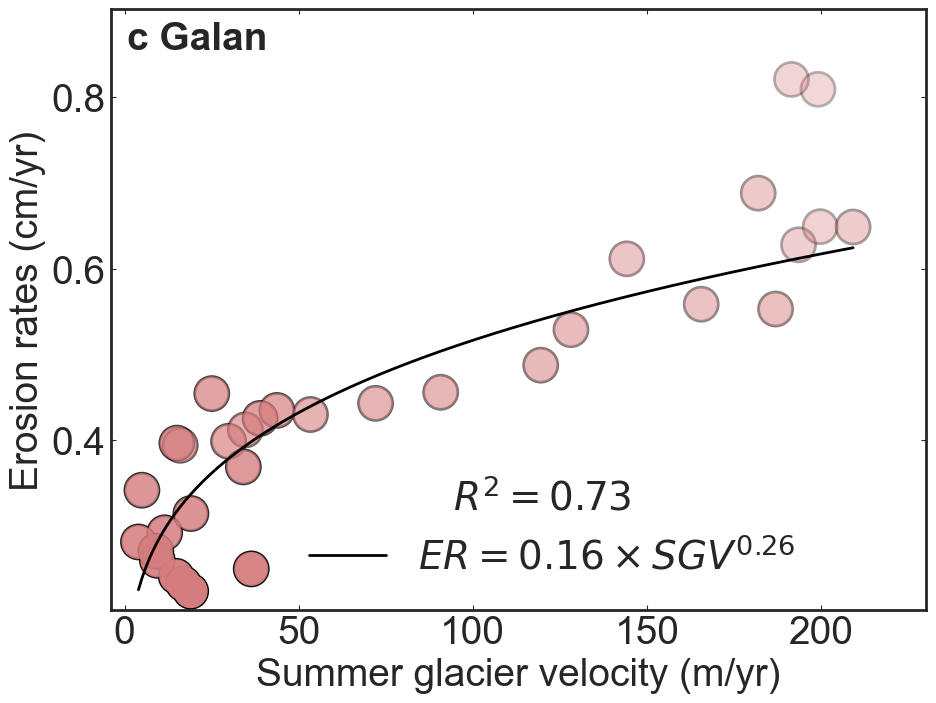

  - Analysis complete! 'TP_Table0926' Figure A saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Bayesian_Analysis_TP_Table0926_A_only.png
  - Bayesian model R² = 0.730

Analysis Results Summary:
          Sheet  Bayesian_l  Bayesian_Keff  Bayesian_R2  Num_obs
0  TP_Table0926       0.257         0.1582       0.7304       32

Results saved to: D:\Research\02Paper\Figures\SGV&SR_Galan lake\Bayesian_Analysis_Summary_A_only.csv


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy import interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.colors import LinearSegmentedColormap

# Set global plotting style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 28
sns.set_style("white")  # Changed to white instead of whitegrid, remove grid

# %% [markdown]
# ## 1. Parameter Settings

# %%
# File path settings
file_path = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake.xlsx"
output_dir = r"D:\Research\02Paper\Figures\SGV&SR_Galan lake"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Analysis parameters
NUM_SAMPLES = 500000   # Number of parameter samples
PERCENTILE_THRESHOLD = 2.0  # Keep top N% with highest likelihood

# Parameter sampling ranges
KEFF_RANGE = [1e-5, 1e2]  # Range of Keff
L_RANGE = [-0.50, 1.5]        # Range of l

# %% [markdown]
# ## 2. Load Data

# %%
# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: File not found at {file_path}")

# Read all worksheets
sheets_dict = pd.read_excel(file_path, sheet_name=None)
print(f"File loaded successfully, found {len(sheets_dict)} worksheets: {list(sheets_dict.keys())}")

# %% [markdown]
# ## 3. Data Processing Function

# %%
def process_sheet(df, sheet_name):
    """Process data from a single worksheet"""
    print(f"\n{'=' * 20} Start analyzing worksheet: {sheet_name} {'=' * 20}")
    
    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # Check if required columns exist
    required_cols = ['Sed', 'S_GV', 'year']  # Added year column
    if not all(col in df.columns for col in required_cols):
        if df.shape[1] >= 3:
            # Try to use the first three columns
            df = df.iloc[:, [1, 2, 3]] if df.shape[1] > 3 else df.iloc[:, :3]
            df.columns = ['Sed', 'S_GV', 'year']
            print(f"  - Warning: Complete column names not found in worksheet '{sheet_name}', automatically using columns 2, 3, 4 data.")
        else:
            print(f"  - Error: Worksheet '{sheet_name}' has insufficient data columns, skipped.")
            return None
    
    # Convert data types and remove invalid values
    df = df[['Sed', 'S_GV', 'year']].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check data validity
    if df.empty:
        print(f"  - Error: Worksheet '{sheet_name}' has no valid data, skipped.")
        return None
    
    if (df['S_GV'] <= 0).any() or (df['Sed'] <= 0).any():
        print(f"  - Error: Worksheet '{sheet_name}' contains invalid (0 or negative) data, logarithmic calculation cannot proceed, skipped.")
        return None
    
    print(f"  - Data preparation complete, total {len(df)} valid observations.")
    print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
    
    return df['S_GV'].values, df['Sed'].values, df['year'].values

# %% [markdown]
# ## 4. Linear Regression Fitting Function (Based on Logarithmic Transformation)

# %%
def linear_regression_fit(gv_obs, ssy_obs):
    """
    Use linear regression to fit log-transformed data: ln(Sed) = ln(Kg) + l * ln(S_GV)
    Equivalent to: y = a + b*x
    """
    # Logarithmic transformation
    ln_sed = np.log(ssy_obs)
    ln_gv = np.log(gv_obs)
    
    # Linear regression fitting
    slope, intercept, r_value, p_value, std_err = stats.linregress(ln_gv, ln_sed)
    
    # Calculate R²
    r_squared = r_value ** 2
    
    # Convert back to original parameters
    # ln(Sed) = ln(Kg) + l * ln(S_GV)
    # So: a = ln(Kg), b = l
    Kg = np.exp(intercept)  # Kg = exp(a)
    l = slope              # l = b
    
    print(f"  - Linear regression fitting results:")
    print(f"    ln(Kg) = {intercept:.4f} -> Kg = {Kg:.4f}")
    print(f"    l = {l:.4f}")
    print(f"    R² = {r_squared:.4f}")
    print(f"    p-value = {p_value:.4f}")
    
    return {
        'Kg': Kg,
        'l': l,
        'ln_Kg': intercept,
        'R_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err
    }

# %% [markdown]
# ## 5. Parameter Sampling and Likelihood Calculation Function (Using Natural Logarithm)

# %%
def calculate_likelihood(gv_obs, ssy_obs):
    """Calculate parameter likelihood (using natural logarithm)"""
    # Parameter sampling
    l_samples = np.random.uniform(L_RANGE[0], L_RANGE[1], NUM_SAMPLES)
    
    # Sampling using natural logarithm range
    ln_keff_min = np.log(KEFF_RANGE[0])
    ln_keff_max = np.log(KEFF_RANGE[1])
    ln_keff_samples = np.random.uniform(ln_keff_min, ln_keff_max, NUM_SAMPLES)
    keff_samples = np.exp(ln_keff_samples)  # Exponential transform back to linear space
    
    # Calculate statistics of observations in log space (using natural logarithm)
    ln_ssy_obs = np.log(ssy_obs)
    sigma = np.std(ln_ssy_obs)
    if sigma == 0: sigma = 1e-9  # Avoid division by zero
    
    # Calculate model predictions
    predicted_ssy_matrix = keff_samples * (gv_obs[:, np.newaxis] ** l_samples)
    
    # Calculate sum of squared standardized residuals in log space (using natural logarithm)
    ln_predicted_ssy_matrix = np.log(predicted_ssy_matrix)
    ln_residuals = (ln_predicted_ssy_matrix - ln_ssy_obs[:, np.newaxis]) / sigma
    chi_squared_per_model = np.sum(ln_residuals ** 2, axis=0)
    
    # Calculate likelihood function values
    likelihood_per_model = np.exp(-0.5 * chi_squared_per_model)
    
    return l_samples, keff_samples, ln_keff_samples, likelihood_per_model

# %% [markdown]
# ## 6. Result Visualization Function (Only Figure A)

# %%
def plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, likelihood_per_model, linear_results):
    """Generate result visualization (only Figure A)"""
    # Determine best fit parameters
    max_likelihood_idx = np.argmax(likelihood_per_model)
    l_best_fit = l_samples[max_likelihood_idx]
    keff_best_fit = keff_samples[max_likelihood_idx]
    ln_keff_best_fit = ln_keff_samples[max_likelihood_idx]
    
    # Filter high likelihood parameters
    likelihood_threshold = np.percentile(likelihood_per_model, 100 - PERCENTILE_THRESHOLD)
    accepted_indices = np.where(likelihood_per_model >= likelihood_threshold)[0]
    
    if len(accepted_indices) == 0:
        print(f"  - Warning: No qualified parameters found. Skipping this worksheet.")
        return
    
    accepted_keff = keff_samples[accepted_indices]
    accepted_ln_keff = ln_keff_samples[accepted_indices]
    accepted_l = l_samples[accepted_indices]
    
    print(f"  - '{sheet_name}' Bayesian best fit model: l = {l_best_fit:.2f}, K_eff = {keff_best_fit:.4f}, ln(K_eff) = {ln_keff_best_fit:.4f}")
    
    # Calculate R² value for Bayesian model
    predicted_ssy_bayesian = keff_best_fit * (gv_obs ** l_best_fit)
    ss_total = np.sum((np.log(ssy_obs) - np.mean(np.log(ssy_obs))) ** 2)
    ss_residual_bayesian = np.sum((np.log(ssy_obs) - np.log(predicted_ssy_bayesian)) ** 2)
    r_squared_bayesian = 1 - (ss_residual_bayesian / ss_total)
    
    # Create single figure (only Figure A)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Figure A: Erosion rate vs. Velocity (only show Bayesian fit)
    # Add inward ticks - show ticks on all four sides
    ax.tick_params(axis='both', direction='in', which='both', top=True, right=True, bottom=True, left=True)

    # Set subplot border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2)  # Set border line thickness, can adjust this value
        
    # Calculate transparency based on year: more recent years are more transparent
    year_min = np.min(year_obs)
    year_max = np.max(year_obs)
    
    # Calculate transparency: more recent years, lower alpha value (more transparent)
    alpha_values_year = 0.3 + 0.7 * (year_max - year_obs) / (year_max - year_min)
    alpha_values_year = np.clip(alpha_values_year, 0.3, 1.0)
    
    # Plot observation data points - using #D57D7E color, transparency based on year
    # First draw outer ring (black border)
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='none', edgecolors='black', 
               linewidths=2, s=600, alpha=alpha_values_year[i])
    # Then draw inner filled points    
    for i in range(len(gv_obs)):
        ax.scatter(gv_obs[i], ssy_obs[i], c='#D57D7E', alpha=alpha_values_year[i], s=600, edgecolors='none')
   
    
    # Generate fitting curve range
    gv_fit = np.linspace(max(1e-9, gv_obs.min()), gv_obs.max(), 200)
    
    # Plot Bayesian best fit curve (power law model)
    ssy_fit_bayesian = keff_best_fit * (gv_fit ** l_best_fit)
    ax.plot(gv_fit, ssy_fit_bayesian, color='black', linewidth=2, 
            label=f'$ER = {keff_best_fit:.2f} \\times SGV^{{{l_best_fit:.2f}}}$')
    
    # Add R² annotation (only show Bayesian R²)
    ax.text(0.42, 0.22, f'$R^2 = {r_squared_bayesian:.2f}$', transform=ax.transAxes, 
            fontsize=28, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Summer glacier velocity (m/yr)', fontsize=28)
    ax.set_ylabel('Erosion rates (cm/yr)', fontsize=28)
    
    # Legend position
    legend = ax.legend(loc='upper left', bbox_to_anchor=(0.2, 0.18), frameon=False, fontsize=28)

    ax.set_xlim(gv_obs.min()-8, gv_obs.max()*1.1)
    ax.set_ylim(ssy_obs.min()*0.9, ssy_obs.max()*1.1)
    ax.text(0.02, 0.98, 'c Galan', transform=ax.transAxes, fontsize=28, fontweight='bold', va='top')
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    output_file = os.path.join(output_dir, f"Bayesian_Analysis_{sheet_name}_A_only.png")
    plt.savefig(output_file, dpi=500, bbox_inches='tight')
    plt.show()
    
    print(f"  - Analysis complete! '{sheet_name}' Figure A saved to: {output_file}")
    print(f"  - Bayesian model R² = {r_squared_bayesian:.3f}")
    
    return l_best_fit, keff_best_fit, r_squared_bayesian

# %% [markdown]
# ## 7. Main Analysis Loop

# %%
# Store all results
results = []

# Loop through each worksheet
for sheet_name, df in sheets_dict.items():
    # Process data
    data = process_sheet(df, sheet_name)
    if data is None:
        continue
    
    gv_obs, ssy_obs, year_obs = data
    
    # Perform linear regression fitting (for calculation only, not displayed)
    print(f"  - Performing linear regression fitting...")
    linear_results = linear_regression_fit(gv_obs, ssy_obs)
    
    # Calculate Bayesian likelihood (using natural logarithm)
    print(f"  - Performing Bayesian analysis...")
    l_samples, keff_samples, ln_keff_samples, likelihood_per_model = calculate_likelihood(gv_obs, ssy_obs)
    
    # Visualize results (only Figure A)
    best_params = plot_results(sheet_name, gv_obs, ssy_obs, year_obs, l_samples, keff_samples, ln_keff_samples, likelihood_per_model, linear_results)
    
    if best_params:
        results.append({
            'Sheet': sheet_name,
            'Bayesian_l': best_params[0],
            'Bayesian_Keff': best_params[1],
            'Bayesian_R2': best_params[2],
            'Num_obs': len(ssy_obs)
        })

# %% [markdown]
# ## 8. Results Summary

# %%
# Display summary results
if results:
    results_df = pd.DataFrame(results)
    print("\nAnalysis Results Summary:")
    print(results_df.round(4))
    
    # Save results to CSV
    results_file = os.path.join(output_dir, "Bayesian_Analysis_Summary_A_only.csv")
    results_df.to_csv(results_file, index=False)
    print(f"\nResults saved to: {results_file}")
else:
    print("\nNo analysis results generated.")